# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia and therefore YLDs.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import vivarium.gbd_mapping as gbd_mapping
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import (
    hemoglobin_pdf_from_mean_sd,
    hemoglobin_cdf_from_mean_sd,
)

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "india"
vehicle = "rice"

In [5]:
# Parameters
location = "nigeria"
vehicle = "rice"


In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
# Must equal the SMALLEST draw count any source here returns, because frames
# from different sources get divided by each other and pandas aligns on column
# name -- a mismatch silently leaves the surplus columns NaN rather than
# raising. Under GBD 2023 get_modelable_entity_draws returns 1,000 while
# vivarium_inputs.get_measure returns 250, so 250 it is. This was 500, which sat
# below both GBD 2021 counts and so silently truncated the 1,000-draw pulls;
# under GBD 2023 it exceeds the 250 and raises KeyError instead.
DRAWS = [f"draw_{i}" for i in range(250)]

In [8]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [9]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [10]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [11]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [12]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.081648,intervention
1,1,Male,0.081648,intervention
2,2,Female,0.108864,intervention
3,2,Male,0.108864,intervention
4,3,Female,0.132678,intervention
5,3,Male,0.132678,intervention
6,4,Female,0.153819,intervention
7,4,Male,0.153819,intervention
8,5,Female,0.164268,intervention
9,5,Male,0.164268,intervention


In [13]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [14]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.081648,intervention,0,125
1,1,Male,0.081648,intervention,0,125
2,2,Female,0.108864,intervention,0,125
3,2,Male,0.108864,intervention,0,125
4,3,Female,0.132678,intervention,0,125
5,3,Male,0.132678,intervention,0,125
6,4,Female,0.153819,intervention,0,125
7,4,Male,0.153819,intervention,0,125
8,5,Female,0.164268,intervention,0,125
9,5,Male,0.164268,intervention,0,125


In [15]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [16]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  17452.628925
                               2                  17380.997496
                               3                  16409.683914
                               4                  14424.706826
                               5                  13407.888483
                                                      ...     
Male    95.0       125.000000  1                   5056.112334
                               2                   4424.735951
                               3                   4548.244848
                               4                   4870.219344
                               5                   5193.002126
Name: value, Length: 250, dtype: float64

In [17]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [18]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

9984802.005639391

In [19]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

1249754.3578602837

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

7562913.436395377

In [21]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [22]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [23]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [24]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [25]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [26]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.to_frame()
            .assign(sex="Female")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.to_frame()
            .assign(sex="Male")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [27]:
effective_coverage_intervention = effective_coverage_intervention.reorder_levels(
    ["sex", "age_start", "age_end", "wealth_quintile", "scenario"]
)

In [28]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [29]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.081648
Name: value, dtype: float64

In [30]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distribution statistics

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [32]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        # year must track vivarium_gates_lsff_2026_child metadata.GBD_EXTRACT_YEAR:
        # GBD 2023 does not estimate these MEs for 2021 at all.
        me_id=me_id, location_id=location_id, year_id=2023, data_type="draws"
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [33]:
gbd_hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
gbd_hgb_mean

/tmp/ipykernel_4159273/770264173.py:2: DeprecationWarning: get_location_id is deprecated. Use resolve_location instead.
  location_id = utility_data.get_location_id(location.title())
2026-08-24 22:53:15.817 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:15.890 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:15.896 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:15.925 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:15.926 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


...

2026-08-24 22:53:15.968 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:15.987 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:15.988 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:15.998 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_bins'


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.966535  143.650481  133.997407  148.190371   
       0.019178  0.076712    134.006805  127.512643  118.944006  131.542517   
       0.076712  0.500000    109.241985  103.947961   96.962831  107.233104   
       0.500000  1.000000    103.694886  103.682815   98.315023  103.747742   
       1.000000  2.000000    101.511831  104.165424   98.846623  101.995650   
       2.000000  5.000000    104.916754  109.845023  104.383710  106.871336   
       5.000000  10.000000   123.272286  117.298335  109.416082  121.005399   
       10.000000 15.000000   126.642119  120.610383  112.619832  124.402089   
       15.000000 20.000000   118.227214  121.866247  115.827596  119.089232   
       20.000000 25.000000   118.968611  122.123275  115.996842  119.790549   
       25.000000 30.000000   119.861264  123.347475  117.277224  120.837675   
       30.000000 35.000000   119.384428  121.659763  115.701678  120.277687   
       35.000000 40.000000   119.445220  121.926524  115.779217  120.042509   
       40.000000 45.000000   119.831319  121.629345  115.347956  120.269489   
       45.000000 50.000000   121.704726  122.854424  116.633593  122.508448   
       50.000000 55.000000   129.174888  122.914887  114.655212  126.799455   
       55.000000 60.000000   130.115834  123.810234  115.490393  127.723099   
       60.000000 65.000000   130.868195  124.526135  116.158186  128.461624   
       65.000000 70.000000   131.234233  124.874434  116.483080  128.820931   
       70.000000 75.000000   132.076356  125.675746  117.230545  129.647568   
       75.000000 80.000000   130.841224  124.500470  116.134246  128.435148   
       80.000000 85.000000   130.736069  124.400411  116.040911  128.331927   
       85.000000 90.000000   130.353796  124.036664  115.701606  127.956684   
       90.000000 95.000000   127.510665  121.331316  113.178053  125.165837   
       95.000000 125.000000  125.441553  119.362476  111.341516  123.134774   
Male   0.000000  0.019178    156.588432  149.302409  139.665609  153.825399   
       0.019178  0.076712    133.015174  126.826008  118.639959  130.668095   
       0.076712  0.500000    107.376553  102.380347   95.772156  105.481873   
       0.500000  1.000000    103.116685  100.955157   95.954311  102.732580   
       1.000000  2.000000    101.306006  100.983658   95.990736  101.285462   
       2.000000  5.000000    104.606000  108.148971  102.732963  105.015538   
       5.000000  10.000000   123.340264  117.601270  110.010636  121.163901   
       10.000000 15.000000   131.025597  124.929006  116.865400  128.713625   
       15.000000 20.000000   144.468172  137.746101  128.855209  141.919003   
       20.000000 25.000000   148.986555  142.054245  132.885282  146.357658   
       25.000000 30.000000   148.905019  141.976503  132.812557  146.277561   
       30.000000 35.000000   150.431806  143.432249  134.174342  147.777408   
       35.000000 40.000000   153.550609  146.405934  136.956089  150.841178   
       40.000000 45.000000   153.352345  146.216896  136.779252  150.646413   
       45.000000 50.000000   151.777246  144.715086  135.374378  149.099107   
       50.000000 55.000000   150.238388  143.247831  134.001827  147.587403   
       55.000000 60.000000   147.906503  141.024448  131.921953  145.296664   
       60.000000 65.000000   145.847334  139.061092  130.085323  143.273830   
       65.000000 70.000000   141.482410  134.899266  126.192124  138.985925   
       70.000000 75.000000   137.258596  130.871986  122.424787  134.836642   
       75.000000 80.000000   131.279762  125.171346  117.092098  128.963306   
       80.000000 85.000000   126.718828  120.822630  113.024072  124.482849   
       85.000000 90.000000   121.493846  115.840766  108.363765  119.350064   
       90.000000 95.000000   115.465006  110.092446  102.986473  113.427604   
    

In [34]:
gbd_hgb_mean.loc[("Female", 25, 30)].mean()

118.96045746053272

In [35]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                   97.093264
                               2                   99.647180
                               3                  102.658490
                               4                  103.792784
                               5                  107.778540
                                                     ...    
Male    95.0       125.000000  1                  113.444966
                               2                  115.420130
                               3                  116.087185
                               4                  116.578539
                               5                  118.793246
Name: value, Length: 250, dtype: float64

In [36]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.220707,0.219801,0.207518,0.182416,0.169557
1,Female,5.0,15.0,not_pregnant,0.222903,0.211314,0.200941,0.189893,0.174949
2,Female,15.0,30.0,not_pregnant,0.165248,0.194708,0.200403,0.223650,0.215992
3,Female,15.0,30.0,pregnant,0.229568,0.269087,0.218290,0.169175,0.113880
4,Female,30.0,50.0,not_pregnant,0.167414,0.176150,0.188366,0.214621,0.253449
5,Female,30.0,50.0,pregnant,0.247900,0.197054,0.182014,0.163763,0.209268
6,Female,50.0,125.0,not_pregnant,0.196077,0.184902,0.228885,0.192974,0.197161
7,Male,0.0,5.0,not_pregnant,0.214963,0.223211,0.203137,0.188194,0.170495
8,Male,5.0,15.0,not_pregnant,0.227134,0.211917,0.202795,0.189340,0.168813
9,Male,15.0,30.0,not_pregnant,0.194480,0.197231,0.196587,0.211924,0.199779


In [37]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.220707
                               2                  0.219801
                               3                  0.207518
                               4                  0.182416
                               5                  0.169557
                                                    ...   
Male    95.0       125.000000  1                  0.209864
                               2                  0.183658
                               3                  0.188784
                               4                  0.202148
                               5                  0.215546
Name: value, Length: 250, dtype: float64

In [38]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [39]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [40]:
hgb_mean = distribute_by_disparities(gbd_hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.966535  143.650481  133.997407  148.190371   
       0.019178  0.076712    134.006805  127.512643  118.944006  131.542517   
       0.076712  0.500000    109.241985  103.947961   96.962831  107.233104   
       0.500000  1.000000    103.694886  103.682815   98.315023  103.747742   
       1.000000  2.000000    101.511831  104.165424   98.846623  101.995650   
       2.000000  5.000000    104.916754  109.845023  104.383710  106.871336   
       5.000000  10.000000   123.272286  117.298335  109.416082  121.005399   
       10.000000 15.000000   126.642119  120.610383  112.619832  124.402089   
       15.000000 20.000000   118.227214  121.866247  115.827596  119.089232   
       20.000000 25.000000   118.968611  122.123275  115.996842  119.790549   
       25.000000 30.000000   119.861264  123.347475  117.277224  120.837675   
       30.000000 35.000000   119.384428  121.659763  115.701678  120.277687   
       35.000000 40.000000   119.445220  121.926524  115.779217  120.042509   
       40.000000 45.000000   119.831319  121.629345  115.347956  120.269489   
       45.000000 50.000000   121.704726  122.854424  116.633593  122.508448   
       50.000000 55.000000   129.174888  122.914887  114.655212  126.799455   
       55.000000 60.000000   130.115834  123.810234  115.490393  127.723099   
       60.000000 65.000000   130.868195  124.526135  116.158186  128.461624   
       65.000000 70.000000   131.234233  124.874434  116.483080  128.820931   
       70.000000 75.000000   132.076356  125.675746  117.230545  129.647568   
       75.000000 80.000000   130.841224  124.500470  116.134246  128.435148   
       80.000000 85.000000   130.736069  124.400411  116.040911  128.331927   
       85.000000 90.000000   130.353796  124.036664  115.701606  127.956684   
       90.000000 95.000000   127.510665  121.331316  113.178053  125.165837   
       95.000000 125.000000  125.441553  119.362476  111.341516  123.134774   
Male   0.000000  0.019178    156.588432  149.302409  139.665609  153.825399   
       0.019178  0.076712    133.015174  126.826008  118.639959  130.668095   
       0.076712  0.500000    107.376553  102.380347   95.772156  105.481873   
       0.500000  1.000000    103.116685  100.955157   95.954311  102.732580   
       1.000000  2.000000    101.306006  100.983658   95.990736  101.285462   
       2.000000  5.000000    104.606000  108.148971  102.732963  105.015538   
       5.000000  10.000000   123.340264  117.601270  110.010636  121.163901   
       10.000000 15.000000   131.025597  124.929006  116.865400  128.713625   
       15.000000 20.000000   144.468172  137.746101  128.855209  141.919003   
       20.000000 25.000000   148.986555  142.054245  132.885282  146.357658   
       25.000000 30.000000   148.905019  141.976503  132.812557  146.277561   
       30.000000 35.000000   150.431806  143.432249  134.174342  147.777408   
       35.000000 40.000000   153.550609  146.405934  136.956089  150.841178   
       40.000000 45.000000   153.352345  146.216896  136.779252  150.646413   
       45.000000 50.000000   151.777246  144.715086  135.374378  149.099107   
       50.000000 55.000000   150.238388  143.247831  134.001827  147.587403   
       55.000000 60.000000   147.906503  141.024448  131.921953  145.296664   
       60.000000 65.000000   145.847334  139.061092  130.085323  143.273830   
       65.000000 70.000000   141.482410  134.899266  126.192124  138.985925   
       70.000000 75.000000   137.258596  130.871986  122.424787  134.836642   
       75.000000 80.000000   131.279762  125.171346  117.092098  128.963306   
       80.000000 85.000000   126.718828  120.822630  113.024072  124.482849   
       85.000000 90.000000   121.493846  115.840766  108.363765  119.350064   
       90.000000 95.000000   115.465006  110.092446  102.986473  113.427604   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.019178  0.076712    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.076712  0.500000    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.500000  1.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       1.000000  2.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       2.000000  5.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       5.000000  10.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       10.000000 15.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       15.000000 20.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       20.000000 25.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       25.0000

In [41]:
gbd_hgb_mean.columns.name = "draw"
gbd_hgb_mean = gbd_hgb_mean.stack().rename("mean")

In [42]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [43]:
gbd_hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
gbd_hgb_sd

/tmp/ipykernel_4159273/770264173.py:2: DeprecationWarning: get_location_id is deprecated. Use resolve_location instead.
  location_id = utility_data.get_location_id(location.title())
2026-08-24 22:53:17.755 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:17.755 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:17.759 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:17.766 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:17.766 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


...

2026-08-24 22:53:17.808 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:17.824 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:17.825 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:17.828 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_bins'


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    23.621065  22.215483  28.427704  15.125453   
       0.019178  0.076712    27.123463  15.906641  18.329904  17.526012   
       0.076712  0.500000    24.309039  15.094109  15.585073  16.877107   
       0.500000  1.000000    20.916076  19.628703  16.244995  18.214384   
       1.000000  2.000000    19.205029  20.909722  17.911274  18.200277   
       2.000000  5.000000    19.816279  22.756450  21.188596  20.475546   
       5.000000  10.000000   25.452569  13.914614  12.949282  17.088616   
       10.000000 15.000000   30.939697  20.600019  15.570055  22.803204   
       15.000000 20.000000   21.579375  22.760652  19.893218  18.540696   
       20.000000 25.000000   22.760269  23.941451  21.282370  19.981375   
       25.000000 30.000000   21.988581  23.455800  20.719747  19.241083   
       30.000000 35.000000   23.061750  23.685724  20.346336  20.836623   
       35.000000 40.000000   22.033548  23.556182  20.400433  19.097314   
       40.000000 45.000000   22.308178  23.037016  19.111012  18.708905   
       45.000000 50.000000   23.139494  23.035746  19.505846  19.987613   
       50.000000 55.000000   33.268652  22.614094  16.611855  24.835823   
       55.000000 60.000000   34.474839  23.763969  17.692532  25.948388   
       60.000000 65.000000   35.390745  24.626843  18.538050  26.773881   
       65.000000 70.000000   35.815396  25.030459  18.917551  27.171933   
       70.000000 75.000000   36.876939  26.047348  19.793564  28.206914   
       75.000000 80.000000   34.300588  23.595207  17.699988  25.694504   
       80.000000 85.000000   32.134002  21.388993  16.308492  23.307836   
       85.000000 90.000000   31.683473  20.913376  16.299984  22.762173   
       90.000000 95.000000   30.291060  19.615609  16.063154  21.540497   
       95.000000 125.000000  29.927858  19.622622  17.042529  21.602100   
Male   0.000000  0.019178     9.713557  10.619283  26.342881   5.385895   
       0.019178  0.076712    20.767733   9.393146  17.400520  10.167586   
       0.076712  0.500000    24.774006  15.991276  15.249446  17.709719   
       0.500000  1.000000    23.384565  20.200345  14.576443  20.707517   
       1.000000  2.000000    22.098436  22.909945  16.278799  21.263117   
       2.000000  5.000000    21.646605  23.553441  18.845936  20.419915   
       5.000000  10.000000   26.198109  14.086321  12.941044  15.621210   
       10.000000 15.000000   30.039624  18.199545  15.690825  19.125579   
       15.000000 20.000000   33.940108  22.446467  21.382560  23.098864   
       20.000000 25.000000   34.828635  23.532269  22.161507  24.389115   
       25.000000 30.000000   34.413811  23.164875  21.812009  24.039456   
       30.000000 35.000000   32.815397  22.006534  20.496299  23.074072   
       35.000000 40.000000   30.479589  20.592825  18.589938  22.035951   
       40.000000 45.000000   30.677050  20.709875  18.783031  22.116463   
       45.000000 50.000000   30.831272  20.639401  18.872160  21.967207   
       50.000000 55.000000   31.834244  21.233287  19.640471  22.426648   
       55.000000 60.000000   31.816297  20.922585  19.542479  21.987908   
       60.000000 65.000000   32.235115  20.992493  19.930108  21.848489   
       65.000000 70.000000   32.945724  21.188265  20.611375  21.723802   
       70.000000 75.000000   34.379967  22.356930  22.003699  22.529229   
       75.000000 80.000000   39.054935  28.529186  25.726509  28.913103   
       80.000000 85.000000   45.855737  37.687634  29.418411  40.602527   
       85.000000 90.000000   54.358463  50.959911  32.923384  54.999998   
       90.000000 95.000000   54.999754  54.999999  33.098108  54.999999   
       95.000000 125.000000  46.450054  50.966017  26.503584  54.999999   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [44]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  16.607283
                               2                  15.898899
                               3                  15.268520
                               4                  14.286274
                               5                  13.194608
                                                    ...    
Male    95.0       125.000000  1                  15.148809
                               2                  14.920351
                               3                  15.108541
                               4                  14.792239
                               5                  14.222341
Name: value, Length: 250, dtype: float64

In [45]:
hgb_sd = distribute_by_disparities(gbd_hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    23.621065  22.215483  28.427704  15.125453   
       0.019178  0.076712    27.123463  15.906641  18.329904  17.526012   
       0.076712  0.500000    24.309039  15.094109  15.585073  16.877107   
       0.500000  1.000000    20.916076  19.628703  16.244995  18.214384   
       1.000000  2.000000    19.205029  20.909722  17.911274  18.200277   
       2.000000  5.000000    19.816279  22.756450  21.188596  20.475546   
       5.000000  10.000000   25.452569  13.914614  12.949282  17.088616   
       10.000000 15.000000   30.939697  20.600019  15.570055  22.803204   
       15.000000 20.000000   21.579375  22.760652  19.893218  18.540696   
       20.000000 25.000000   22.760269  23.941451  21.282370  19.981375   
       25.000000 30.000000   21.988581  23.455800  20.719747  19.241083   
       30.000000 35.000000   23.061750  23.685724  20.346336  20.836623   
       35.000000 40.000000   22.033548  23.556182  20.400433  19.097314   
       40.000000 45.000000   22.308178  23.037016  19.111012  18.708905   
       45.000000 50.000000   23.139494  23.035746  19.505846  19.987613   
       50.000000 55.000000   33.268652  22.614094  16.611855  24.835823   
       55.000000 60.000000   34.474839  23.763969  17.692532  25.948388   
       60.000000 65.000000   35.390745  24.626843  18.538050  26.773881   
       65.000000 70.000000   35.815396  25.030459  18.917551  27.171933   
       70.000000 75.000000   36.876939  26.047348  19.793564  28.206914   
       75.000000 80.000000   34.300588  23.595207  17.699988  25.694504   
       80.000000 85.000000   32.134002  21.388993  16.308492  23.307836   
       85.000000 90.000000   31.683473  20.913376  16.299984  22.762173   
       90.000000 95.000000   30.291060  19.615609  16.063154  21.540497   
       95.000000 125.000000  29.927858  19.622622  17.042529  21.602100   
Male   0.000000  0.019178     9.713557  10.619283  26.342881   5.385895   
       0.019178  0.076712    20.767733   9.393146  17.400520  10.167586   
       0.076712  0.500000    24.774006  15.991276  15.249446  17.709719   
       0.500000  1.000000    23.384565  20.200345  14.576443  20.707517   
       1.000000  2.000000    22.098436  22.909945  16.278799  21.263117   
       2.000000  5.000000    21.646605  23.553441  18.845936  20.419915   
       5.000000  10.000000   26.198109  14.086321  12.941044  15.621210   
       10.000000 15.000000   30.039624  18.199545  15.690825  19.125579   
       15.000000 20.000000   33.940108  22.446467  21.382560  23.098864   
       20.000000 25.000000   34.828635  23.532269  22.161507  24.389115   
       25.000000 30.000000   34.413811  23.164875  21.812009  24.039456   
       30.000000 35.000000   32.815397  22.006534  20.496299  23.074072   
       35.000000 40.000000   30.479589  20.592825  18.589938  22.035951   
       40.000000 45.000000   30.677050  20.709875  18.783031  22.116463   
       45.000000 50.000000   30.831272  20.639401  18.872160  21.967207   
       50.000000 55.000000   31.834244  21.233287  19.640471  22.426648   
       55.000000 60.000000   31.816297  20.922585  19.542479  21.987908   
       60.000000 65.000000   32.235115  20.992493  19.930108  21.848489   
       65.000000 70.000000   32.945724  21.188265  20.611375  21.723802   
       70.000000 75.000000   34.379967  22.356930  22.003699  22.529229   
       75.000000 80.000000   39.054935  28.529186  25.726509  28.913103   
       80.000000 85.000000   45.855737  37.687634  29.418411  40.602527   
       85.000000 90.000000   54.358463  50.959911  32.923384  54.999998   
       90.000000 95.000000   54.999754  54.999999  33.098108  54.999999   
       95.000000 125.000000  46.450054  50.966017  26.503584  54.999999   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.019178  0.076712    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.076712  0.500000    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.500000  1.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       1.000000  2.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       2.000000  5.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       5.000000  10.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       10.000000 15.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       15.000000 20.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       20.000000 25.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                25.856098  24.317520  31.117544   
                            2                24.753205  23.280255  29.790223   
                            3                23.771759  22.357211  28.609064   
                            4                22.242488  20.918940  26.768602   
                            5                20.542859  19.320448  24.723116   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                47.456707  52.070539  27.077962   
                            2                46.741013  51.285264  26.669600   
                            3                47.330558  51.932125  27.005984   
                            4                46.339677  50.844909  26.440604   
                            5                44.554359  48.886019  25.421933   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                16.556629  32.587846  13.637260   
                            2                15.850405  31.197810  13.055562   
                            3                15.221948  29.960841  12.537919   
                            4                14.242699  28.033417  11.731337   
                            5                13.154363  25.891282  10.834903   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                56.191944  21.038016  37.312101   
                            2                55.344514  20.720742  36.749398   
                            3                56.042575  20.982093  37.212919   
                            4                54.869305  20.542825  36.433853   
                            5                52.755368  19.751377  35.030175   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                32.891799  32.908499  28.272598   
                            2                31.488797  31.504785  27.066629   
                            3                30.240291  30.255644  25.993458   
                            4                28.294890  28.309256  24.321262   
                            5                26.132775  26.146043  22.462786   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                28.179659  29.229673  34.507727   
                            2                27.754682  28.788861  33.987316   
                            3                28.104752  29.151975  34.415999   
                            4                27.516369  28.541668  33.695488   
                            5                26.456253  27.442050  32.397310   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                24.226949  32.624055  30.850806   
                            2                23.193548  31.232474  29.534863   
                            3                22.273941  29.994131  28.363829   
                            4                20.841027  28.064566  26.539143   
                            5                19.248489  25.920050  24.511191   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                26.920463  26.978871  35.215554   
                            2                26.514476  26.572003  34.684469   
                            3                26.848903  26.907156  35.121944   
                            4                

In [46]:
gbd_hgb_sd.columns.name = "draw"
gbd_hgb_sd = gbd_hgb_sd.stack().rename("sd")
gbd_hgb_sd

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      23.621065
                               draw_1      22.215483
                               draw_2      28.427704
                               draw_3      15.125453
                               draw_4      29.770912
                                             ...    
Male    95.0       125.000000  draw_245    37.722073
                               draw_246    54.999999
                               draw_247    54.999999
                               draw_248    54.999999
                               draw_249    24.476821
Name: sd, Length: 12500, dtype: float64

In [47]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      25.856098
                                                draw_1      24.317520
                                                draw_2      31.117544
                                                draw_3      16.556629
                                                draw_4      32.587846
                                                              ...    
Male    95.0       125.000000  5                draw_245    36.182579
                                                draw_246    52.755367
                                                draw_247    52.755367
                                                draw_248    52.755368
                                                draw_249    23.477886
Name: sd, Length: 62500, dtype: float64

In [48]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

116.12492234015916

In [49]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

17.970589205967087

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [50]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [51]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [52]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [53]:
len(iron_responsive_anemia_sequelae)

138

In [54]:
len(non_iron_responsive_anemia_sequelae)

60

In [55]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(
                sequela, "prevalence", location.title()
            ).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert "zero" in str(e)
            continue
        except DataAbnormalError as e:
            assert "zero" in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)

    loguru.logger.enable("vivarium_inputs.validation.raw")

    return result

In [56]:
# vivarium_inputs validates population against MAX_POP = 695,000,000 per
# age/sex/year cell -- a sanity ceiling sized for a single country. GBD 2023 puts
# the *Global* 5-9 both-sexes count at 700,543,636, so that ceiling now rejects a
# legitimate aggregate and raises DataAbnormalError. Exactly one cell exceeds it.
# The constant is identical in the old and new library, so this is GBD 2023
# crossing a fixed threshold, not a library regression. Lifted for this one call
# and restored immediately, so every other validation stays active.
import vivarium_inputs.validation.raw as _vi_raw

_max_pop = _vi_raw.MAX_POP
_vi_raw.MAX_POP = float("inf")
try:
    global_population = (
        vivarium_inputs.get_population_structure("Global").droplevel("location").value
    )
finally:
    _vi_raw.MAX_POP = _max_pop
global_population

2026-08-24 22:53:20.688 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:20.689 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:20.693 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:20.700 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:20.701 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


...

2026-08-24 22:53:20.934 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:20.940 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:20.941 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:20.944 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_bins'


sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2023        2024        1.169382e+06
        0.019178   0.076712    2023        2024        3.484011e+06
        0.076712   0.500000    2023        2024        2.565567e+07
        0.500000   1.000000    2023        2024        3.009545e+07
        1.000000   2.000000    2023        2024        6.090771e+07
        2.000000   5.000000    2023        2024        1.904133e+08
        5.000000   10.000000   2023        2024        3.394829e+08
        10.000000  15.000000   2023        2024        3.312048e+08
        15.000000  20.000000   2023        2024        3.140986e+08
        20.000000  25.000000   2023        2024        2.965056e+08
        25.000000  30.000000   2023        2024        2.896126e+08
        30.000000  35.000000   2023        2024        2.944150e+08
        35.000000  40.000000   2023        2024        2.882803e+08
        40.000000  45.000000   2023        2024        2.551532e

In [57]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

2026-08-24 22:53:21.214 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:21.215 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:21.220 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:21.227 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:21.229 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


...

2026-08-24 22:53:45.547 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:45.553 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:45.555 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:45.561 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_bins'


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.045578  0.046219  0.045671   
       0.019178  0.076712   2023       2024      0.049863  0.043073  0.045211   
       0.076712  0.500000   2023       2024      0.050801  0.045918  0.047161   
       0.500000  1.000000   2023       2024      0.047583  0.043008  0.044856   
       1.000000  2.000000   2023       2024      0.048627  0.045214  0.046868   
       2.000000  5.000000   2023       2024      0.046250  0.046825  0.047068   
       5.000000  10.000000  2023       2024      0.055045  0.046194  0.052140   
       10.000000 15.000000  2023       2024      0.053610  0.035507  0.044549   
       15.000000 20.000000  2023       2024      0.053701  0.049667  0.053160   
       20.000000 25.000000  2023       2024      0.053737  0.049797  0.050895   
       25.000000 30.000000  2023       2024      0.051301  0.048516  0.048960   
       30.000000 35.000000  2023       2024      0.048301  0.046825  0.046768   
       35.000000 40.000000  2023       2024      0.047374  0.045653  0.046068   
       40.000000 45.000000  2023       2024      0.047406  0.045043  0.046064   
       45.000000 50.000000  2023       2024      0.043932  0.040883  0.044057   
       50.000000 55.000000  2023       2024      0.043830  0.034350  0.040878   
       55.000000 60.000000  2023       2024      0.039881  0.030024  0.038494   
       60.000000 65.000000  2023       2024      0.049342  0.038222  0.049550   
       65.000000 70.000000  2023       2024      0.045641  0.036414  0.047796   
       70.000000 75.000000  2023       2024      0.042886  0.035202  0.042215   
       75.000000 80.000000  2023       2024      0.045523  0.036062  0.043701   
       80.000000 85.000000  2023       2024      0.042347  0.033395  0.041462   
       85.000000 90.000000  2023       2024      0.036577  0.029210  0.036895   
       90.000000 95.000000  2023       2024      0.036727  0.029834  0.040546   
       95.000000 125.000000 2023       2024      0.034179  0.027805  0.038146   
Male   0.000000  0.019178   2023       2024      0.043624  0.055535  0.045043   
       0.019178  0.076712   2023       2024      0.052826  0.055795  0.050590   
       0.076712  0.500000   2023       2024      0.050557  0.048097  0.050579   
       0.500000  1.000000   2023       2024      0.048093  0.044355  0.047949   
       1.000000  2.000000   2023       2024      0.050922  0.047092  0.046134   
       2.000000  5.000000   2023       2024      0.053707  0.047777  0.046216   
       5.000000  10.000000  2023       2024      0.060280  0.048688  0.053154   
       10.000000 15.000000  2023       2024      0.049842  0.031900  0.039663   
       15.000000 20.000000  2023       2024      0.042560  0.037473  0.041824   
       20.000000 25.000000  2023       2024      0.032605  0.029675  0.032322   
       25.000000 30.000000  2023       2024      0.029532  0.027868  0.030337   
       30.000000 35.000000  2023       2024      0.027871  0.025995  0.028755   
       35.000000 40.000000  2023       2024      0.027544  0.026161  0.028791   
       40.000000 45.000000  2023       2024      0.029782  0.027342  0.030236   
       45.000000 50.000000  2023       2024      0.030540  0.027853  0.030807   
       50.000000 55.000000  2023       2024      0.031237  0.029062  0.030689   
       55.000000 60.000000  2023       2024      0.032731  0.028127  0.034992   
       60.000000 65.000000  2023       2024      0.037746  0.033909  0.041938   
       65.000000 70.000000  2023       2024      0.039095  0.034342  0.042015   
       70.000000 75.000000  2023       2024      0.040174  0.035720  0.042459   
       75.000000 80.000000  2023       2024      0.044304  0.041342  0.045814   
       80.000000 85.000000  2023       2024      0.043023  0.041786  0.046412   
       85.000000 90.000000  2023       2024      0.049052  0.043388  0.047786   
 

In [58]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.043705
draw_1      0.038003
draw_2      0.042088
draw_3      0.045451
draw_4      0.040852
              ...   
draw_245    0.038835
draw_246    0.032406
draw_247    0.034347
draw_248    0.035604
draw_249    0.034705
Length: 250, dtype: float64

In [59]:
global_non_responsive_aggregated.describe()

count    250.000000
mean       0.039116
std        0.004677
min        0.030456
25%        0.035535
50%        0.038269
75%        0.042047
max        0.056658
dtype: float64

In [60]:
global_non_responsive_aggregated.mean()

0.039116124438922525

In [61]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.398533
draw_1      3.378390
draw_2      3.392796
draw_3      3.404750
draw_4      3.388423
              ...   
draw_245    3.381314
draw_246    3.358848
draw_247    3.365598
draw_248    3.369983
draw_249    3.366847
Length: 250, dtype: float64

In [62]:
hemoglobin_effect_among_responsive.mean()

3.382382636570992

## Iron-responsiveness in population of interest

In [63]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

2026-08-24 22:53:51.561 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:51.562 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:53:51.575 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:53:51.583 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:53:51.585 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


...

2026-08-24 22:54:14.275 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_group_id'


2026-08-24 22:54:14.281 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:54:14.282 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:54:14.285 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_path_to_global'


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.066737  0.082084  0.067536   
       0.019178  0.076712   2023       2024      0.120351  0.121402  0.101294   
       0.076712  0.500000   2023       2024      0.128158  0.137253  0.121561   
       0.500000  1.000000   2023       2024      0.169756  0.127266  0.145554   
       1.000000  2.000000   2023       2024      0.172884  0.138212  0.156248   
       2.000000  5.000000   2023       2024      0.156477  0.145213  0.168219   
       5.000000  10.000000  2023       2024      0.274318  0.160009  0.227766   
       10.000000 15.000000  2023       2024      0.205689  0.101090  0.160076   
       15.000000 20.000000  2023       2024      0.185192  0.149110  0.165092   
       20.000000 25.000000  2023       2024      0.167391  0.138658  0.145145   
       25.000000 30.000000  2023       2024      0.162976  0.138017  0.140799   
       30.000000 35.000000  2023       2024      0.170779  0.138306  0.147764   
       35.000000 40.000000  2023       2024      0.187472  0.159141  0.152189   
       40.000000 45.000000  2023       2024      0.193574  0.165441  0.154890   
       45.000000 50.000000  2023       2024      0.197485  0.146224  0.161073   
       50.000000 55.000000  2023       2024      0.178605  0.104323  0.145185   
       55.000000 60.000000  2023       2024      0.165034  0.097322  0.136923   
       60.000000 65.000000  2023       2024      0.164262  0.106307  0.146908   
       65.000000 70.000000  2023       2024      0.150065  0.100966  0.137579   
       70.000000 75.000000  2023       2024      0.132110  0.092731  0.123576   
       75.000000 80.000000  2023       2024      0.140027  0.094824  0.127126   
       80.000000 85.000000  2023       2024      0.141682  0.092060  0.125019   
       85.000000 90.000000  2023       2024      0.140530  0.090722  0.123878   
       90.000000 95.000000  2023       2024      0.153641  0.096599  0.134868   
       95.000000 125.000000 2023       2024      0.143564  0.095399  0.133127   
Male   0.000000  0.019178   2023       2024      0.068403  0.127866  0.072999   
       0.019178  0.076712   2023       2024      0.103717  0.165117  0.100471   
       0.076712  0.500000   2023       2024      0.127115  0.130041  0.120774   
       0.500000  1.000000   2023       2024      0.145301  0.108392  0.142687   
       1.000000  2.000000   2023       2024      0.156702  0.127303  0.148953   
       2.000000  5.000000   2023       2024      0.152178  0.133525  0.153950   
       5.000000  10.000000  2023       2024      0.230964  0.156183  0.198704   
       10.000000 15.000000  2023       2024      0.212598  0.099785  0.138923   
       15.000000 20.000000  2023       2024      0.139742  0.085475  0.111158   
       20.000000 25.000000  2023       2024      0.109642  0.070929  0.092150   
       25.000000 30.000000  2023       2024      0.108937  0.072257  0.091803   
       30.000000 35.000000  2023       2024      0.106278  0.069584  0.091977   
       35.000000 40.000000  2023       2024      0.093165  0.061874  0.086646   
       40.000000 45.000000  2023       2024      0.093854  0.062696  0.086890   
       45.000000 50.000000  2023       2024      0.102085  0.066825  0.091247   
       50.000000 55.000000  2023       2024      0.109723  0.070820  0.095675   
       55.000000 60.000000  2023       2024      0.122808  0.077020  0.103929   
       60.000000 65.000000  2023       2024      0.134419  0.088150  0.117512   
       65.000000 70.000000  2023       2024      0.148686  0.100917  0.125393   
       70.000000 75.000000  2023       2024      0.153248  0.110519  0.126534   
       75.000000 80.000000  2023       2024      0.134380  0.105299  0.119372   
       80.000000 85.000000  2023       2024      0.110681  0.092928  0.114923   
       85.000000 90.000000  2023       2024      0.100732  0.086473  0.114966   
 

In [64]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.066737
                               draw_1      0.082084
                               draw_2      0.067536
                               draw_3      0.060776
                               draw_4      0.073600
                                             ...   
Male    95.0       125.000000  draw_245    0.098104
                               draw_246    0.096266
                               draw_247    0.086579
                               draw_248    0.113997
                               draw_249    0.097574
Length: 12500, dtype: float64

In [65]:
non_iron_responsive_prevalence.sort_values()

sex     age_start  age_end  draw    
Male    40.0       45.0     draw_55     0.036638
        50.0       55.0     draw_178    0.039594
        35.0       40.0     draw_198    0.040786
        40.0       45.0     draw_198    0.041088
        35.0       40.0     draw_55     0.041428
                                          ...   
        5.0        10.0     draw_145    0.278175
Female  5.0        10.0     draw_221    0.284631
                            draw_24     0.285377
                            draw_178    0.287000
                            draw_147    0.288480
Length: 12500, dtype: float64

In [66]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.11502746444089958

## Create sub-population hemoglobin distributions for iron responsiveness and fortification

In [67]:
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_2021 = pd.Series(0, index=effective_coverage_baseline.index)
else:
    effective_coverage_2021 = effective_coverage_baseline

In [68]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

2026-08-24 22:54:24.163 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:54:24.163 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:54:24.167 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:54:24.173 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:54:24.177 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:54:24.180 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_location_ids'


2026-08-24 22:54:24.187 | DEBUG    | vivarium_gbd_access.utilities:get_memory:61 - Config: 'input_data:
    intermediary_data_cache_path:
        user_configs: /mnt/team/simulation_science/costeffectiveness/vivarium_cache
    cache_data:
        base: True'


2026-08-24 22:54:24.188 | DEBUG    | vivarium_gbd_access.utilities:get_memory:66 - Cache Dir: '/mnt/team/simulation_science/costeffectiveness/vivarium_cache'


2026-08-24 22:54:24.191 | INFO     | vivarium_gbd_access.utilities:wrapper:47 - Using cached data for 'get_age_bins'


,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [69]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [70]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [71]:
thresholds = (
    thresholds[thresholds.pregnant == 0]
    .drop(columns=["pregnant"])
    .set_index(["sex", "age_start", "age_end"])
)
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end                                        
Female 0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             120   
       20.000000 25.000000                  0             120   
       25.000000 30.000000                  0             120   
       30.000000 35.000000                  0             120   
       35.000000 40.000000                  0             120   
       40.000000 45.000000                  0             120   
       45.000000 50.000000                  0             120   
       50.000000 55.000000                  0             120   
       55.000000 60.000000                  0             120   
       60.000000 65.000000                  0             120   
       65.000000 70.000000                  0             120   
       70.000000 75.000000                  0             120   
       75.000000 80.000000                  0             120   
       80.000000 85.000000                  0             120   
       85.000000 90.000000                  0             120   
       90.000000 95.000000                  0             120   
       95.000000 125.000000                 0             120   
Male   0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             130   
       20.000000 25.000000                  0             130   
       25.000000 30.000000                  0             130   
       30.000000 35.000000                  0             130   
       35.000000 40.000000                  0             130   
       40.000000 45.000000                  0             130   
       45.000000 50.000000                  0             130   
       50.000000 55.000000                  0             130   
       55.000000 60.000000                  0             130   
       60.000000 65.000000                  0             130   
       65.000000 70.000000                  0             130   
       70.000000 75.000000                  0             130   
       75.000000 80.000000                  0             130   
       80.000000 85.000000                  0             130   
       85.000000 90.000000                  0             130   
       90.000000 95.000000                  0             130   
       95.000000 125.000000                 0             130   

                             hgb_upper_moderate  hgb_upper_severe  
sex    age_start age_end                                           
Female 0.000000  0.019178                   145               100  
       0.019178  0.076712                   120                85  
       0.076712  0.500000                   100                70  
       0.500000  1.000000                   100                70  
       1.000000  2.000000                   100                70  
       2.000000  5.000000                   100                70  
       5.000000  10.000000                  110                80  
       10.000000 15.000000          

In [72]:
# Put in a dataframe, to ensure aligned
hgb_info = pd.DataFrame({"mean": hgb_mean, "sd": hgb_sd})
assert hgb_info.notnull().all().all()
hgb_info

mean         sd
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    143.925265  25.856098
                                            draw_1    136.950440  24.317520
                                            draw_2    127.747598  31.117544
                                            draw_3    141.278584  16.556629
                                            draw_4    128.576728  32.587846
...                                                          ...        ...
Male   95.0      125.000000 5               draw_245  110.416026  36.182579
                                            draw_246  114.754289  52.755367
                                            draw_247  109.516231  52.755367
                                            draw_248  109.945364  52.755368
                                            draw_249  101.174580  23.477886

[62500 rows x 2 columns]

In [73]:
hgb_info[thresholds.columns] = thresholds.reindex(hgb_info.index)
hgb_info

mean         sd  \
sex    age_start age_end    wealth_quintile draw                              
Female 0.0       0.019178   1               draw_0    143.925265  25.856098   
                                            draw_1    136.950440  24.317520   
                                            draw_2    127.747598  31.117544   
                                            draw_3    141.278584  16.556629   
                                            draw_4    128.576728  32.587846   
...                                                          ...        ...   
Male   95.0      125.000000 5               draw_245  110.416026  36.182579   
                                            draw_246  114.754289  52.755367   
                                            draw_247  109.516231  52.755367   
                                            draw_248  109.945364  52.755368   
                                            draw_249  101.174580  23.477886   

                                                      hgb_lower_severe  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0                   0   
                                            draw_1                   0   
                                            draw_2                   0   
                                            draw_3                   0   
                                            draw_4                   0   
...                                                                ...   
Male   95.0      125.000000 5               draw_245                 0   
                                            draw_246                 0   
                                            draw_247                 0   
                                            draw_248                 0   
                                            draw_249                 0   

                                                      hgb_upper_mild  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0               160   
                                            draw_1               160   
                                            draw_2               160   
                                            draw_3               160   
                                            draw_4               160   
...                                                              ...   
Male   95.0      125.000000 5               draw_245             130   
                                            draw_246             130   
                                            draw_247             130   
                                            draw_248             130   
                                            draw_249             130   

                                                      hgb_upper_moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0                   145   
                                            draw_1                   145   
                                            draw_2                   145   
                                            draw_3                   145   
                                            draw_4                   145   
...                                                                  ...   
Male   95.0      125.000000 5               draw_245                 110   
                                            draw_246                 110   
                                            draw_247                 110   
                                            draw_248                 110   
                                            draw_249                 110   

                                                      hgb_upper_severe  
sex    age_start age_end    wealth_quintile draw                      

In [74]:
from dataclasses import dataclass
import pandas as pd


@dataclass(frozen=True)
class Distributions:
    data_index: pd.Index
    pdfs: callable
    cdfs: callable

In [75]:
def distributions_from_mean_sd(mean, sd):
    assert mean.index.equals(sd.index)
    return Distributions(
        pdfs=hemoglobin_pdf_from_mean_sd(mean, sd),
        cdfs=hemoglobin_cdf_from_mean_sd(mean, sd),
        data_index=mean.index,
    )

In [76]:
# NOTE: Until recently there was a bug in risk_distributions where calling pdf or cdf with a
# numpy array would modify it! https://jira.ihme.washington.edu/browse/MIC-5595
# This has been fixed, but I haven't yet updated risk_distributions, so I use .copy()
# liberally here to avoid side effects.
# TODO: Update environment and remove .copy()
def truncate_distributions(
    distributions: Distributions, truncate_min=None, truncate_max=None
):
    assert truncate_min is not None or truncate_max is not None
    if truncate_min is not None:
        original_cdfs_at_min = distributions.cdfs(truncate_min)
    else:
        original_cdfs_at_min = 0
    if truncate_max is not None:
        original_cdfs_at_max = distributions.cdfs(truncate_max)
    else:
        original_cdfs_at_max = 1

    def new_pdfs(x):
        outside_bounds = np.full(len(distributions.data_index), False)
        if truncate_min is not None:
            outside_bounds = outside_bounds | (x <= truncate_min)
        if truncate_max is not None:
            outside_bounds = outside_bounds | (x >= truncate_max)
        return np.where(
            outside_bounds,
            0,
            distributions.pdfs(x.copy())
            / (original_cdfs_at_max - original_cdfs_at_min),
        )

    def new_cdfs(x):
        return np.clip(
            (distributions.cdfs(x.copy()) - original_cdfs_at_min)
            / (original_cdfs_at_max - original_cdfs_at_min),
            0,
            1,
        )

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [77]:
def mix_distributions(distributions_with_weights: list[tuple[Distributions, float]]):
    data_index = None
    for dist, weights in distributions_with_weights:
        if data_index is None:
            data_index = dist.data_index
        assert dist.data_index.equals(data_index)
        assert weights.index.equals(data_index)

    def new_pdfs(x):
        weighted_mean = sum(
            [
                dist.pdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    def new_cdfs(x):
        weighted_mean = sum(
            [
                dist.cdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

In [78]:
def delete_from_mixture_distributions(
    main_distributions: Distributions,
    distributions_to_delete: Distributions,
    weight_to_delete,
    test_points=None,
):
    data_index = main_distributions.data_index
    assert distributions_to_delete.data_index.equals(data_index)
    assert weight_to_delete.index.equals(data_index)

    def new_pdfs(x):
        return (
            main_distributions.pdfs(x.copy())
            - weight_to_delete * distributions_to_delete.pdfs(x.copy())
        ) / (1 - weight_to_delete)

    def new_cdfs(x):
        return (
            main_distributions.cdfs(x.copy())
            - weight_to_delete * distributions_to_delete.cdfs(x.copy())
        ) / (1 - weight_to_delete)

    new_distributions = Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index
    )

    # Check that this is the inverse of making a mixture
    mixed_distributions = mix_distributions(
        [
            (new_distributions, 1 - weight_to_delete),
            (distributions_to_delete, weight_to_delete),
        ]
    )
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)
    for test_point in test_points:
        with np.errstate(under="ignore"):
            assert np.allclose(
                mixed_distributions.pdfs(np.full(len(data_index), test_point)),
                main_distributions.pdfs(np.full(len(data_index), test_point)),
            )
            assert np.allclose(
                mixed_distributions.cdfs(np.full(len(data_index), test_point)),
                main_distributions.cdfs(np.full(len(data_index), test_point)),
            )

    return new_distributions

In [79]:
def shift_distributions(distributions, shift):
    def new_pdfs(x):
        # NOTE: Shifts can cause the xmin to become non-zero!
        # Not messing with the hemoglobin distribution right now,
        # so filling with zero instead.
        return distributions.pdfs(x.copy() - shift).fillna(0)

    def new_cdfs(x):
        return distributions.cdfs(x.copy() - shift).fillna(0)

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [80]:
def test_pdfs_cdfs_consistency(
    distributions: Distributions,
    test_points=None,
    data_proportion=0.05,
    mean_tolerance=1e-4,
    max_tolerance=1e-3,
    integration_min=0,
    integration_max=200,
    integration_points=200,
):
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)

    rng = np.random.default_rng(1234)
    data_to_use = rng.random(len(distributions.data_index)) < data_proportion

    x_values_for_integration = np.linspace(
        integration_min, integration_max, num=integration_points
    )
    pdf_values = np.full(
        (integration_points, len(distributions.data_index)), fill_value=np.nan
    )

    for idx, x_value_for_integration in enumerate(x_values_for_integration):
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = x_value_for_integration
            pdf_values[idx, :] = distributions.pdfs(s)

    for test_point in test_points:
        # Round test point to nearest X value for integration
        actual_test_point = x_values_for_integration[
            np.searchsorted(x_values_for_integration, test_point, side="left")
        ]
        # Use PDF at points less than test_point
        use_pdf = x_values_for_integration <= actual_test_point
        # Integrate the PDF numerically to approximate the CDF
        cdf_approx = np.trapz(
            pdf_values[use_pdf, :], x=x_values_for_integration[use_pdf], axis=0
        )

        # Evaluate the CDF directly
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = actual_test_point
            cdf_actual = distributions.cdfs(s)

        difference = pd.Series(cdf_actual - cdf_approx, index=distributions.data_index)[
            data_to_use
        ]
        print(difference.describe())
        display(difference.sort_values())

        # Check if the difference is within the tolerance
        assert difference.abs().mean() <= mean_tolerance
        assert np.allclose(
            cdf_approx[data_to_use], cdf_actual[data_to_use], atol=max_tolerance, rtol=0
        )

In [81]:
import matplotlib.pyplot as plt

example_draw = "draw_33"
example_tuple_with_draw = (*example_tuple, example_draw)


def plot_example_distributions(
    distributions: dict[str, Distributions], plot_cdf=False, plot_integrated_cdf=False
):
    x_values = np.linspace(60, 160, 100)
    with np.errstate(under="ignore"):
        max_y_value = 0
        # Ensure lines are not plotted directly atop each other
        jitter = 0
        for name, distributions in distributions.items():

            def example_pdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.pdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            def example_cdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.cdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            pdf_y_values = np.array([example_pdf(x) for x in x_values])
            max_y_value = max(max_y_value, max(pdf_y_values))
            plt.plot(
                x_values,
                pdf_y_values + jitter,
                label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw}",
            )

            if plot_cdf:
                y_values = np.array([example_cdf(x) for x in x_values])
                max_y_value = max(max_y_value, max(y_values))
                plt.plot(
                    x_values,
                    y_values + jitter,
                    label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF)",
                )

                if plot_integrated_cdf:
                    y_values = [
                        np.trapz(
                            pdf_y_values[x_values <= x],
                            x=x_values[x_values <= x],
                            axis=0,
                        )
                        for x in x_values
                    ]
                    max_y_value = max(max_y_value, max(y_values))
                    plt.plot(
                        x_values,
                        y_values + jitter,
                        label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF integrated)",
                    )

            jitter += 0.0003

        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_mild,
            0,
            max_y_value,
            linestyles="dashed",
            label="Anemia",
            color="lime",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_moderate,
            0,
            max_y_value,
            linestyles="dashed",
            label="Moderate anemia",
            color="gold",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_severe,
            0,
            max_y_value,
            linestyles="dashed",
            label="Severe anemia",
            color="crimson",
        )
        plt.xlabel("Hemoglobin (g/L)")
        plt.ylabel("Probability density")
        plt.legend(bbox_to_anchor=(1.05, 1))

In [82]:
hemoglobin_distributions_by_age_sex_quintile = distributions_from_mean_sd(
    hgb_info["mean"], hgb_info["sd"]
)

In [83]:
# NOTE: We need a lot of wiggle room here, I believe because of the deleterious effects of xmin and xmax!
test_pdfs_cdfs_consistency(
    hemoglobin_distributions_by_age_sex_quintile,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.170089e-03
std      4.174255e-03
min     -4.215423e-07
25%      5.683431e-06
50%      7.120976e-05
75%      4.125419e-04
max      3.435115e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.215423e-07
Female  1.000000   2.0      1                draw_230   -3.343388e-07
        0.076712   0.5      1                draw_183   -3.024550e-07
                            2                draw_107   -2.610426e-07
Male    0.076712   0.5      2                draw_199   -2.511647e-07
                                                             ...     
        90.000000  95.0     3                draw_204    3.097156e-02
                                             draw_126    3.097372e-02
        95.000000  125.0    1                draw_242    3.209781e-02
        90.000000  95.0     1                draw_204    3.282925e-02
        95.000000  125.0    3                draw_57     3.435115e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001141
std         0.004182
min        -0.000226
25%        -0.000010
50%         0.000042
75%         0.000386
max         0.034355
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000226
                                             draw_229   -0.000225
        1.000000   2.0      1                draw_230   -0.000214
Male    0.500000   1.0      2                draw_228   -0.000210
Female  0.076712   0.5      1                draw_183   -0.000206
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.030975
                                             draw_126    0.030978
        95.000000  125.0    1                draw_242    0.032102
        90.000000  95.0     1                draw_204    0.032833
        95.000000  125.0    3                draw_57     0.034355
Length: 3069, dtype: float64

count    3069.000000
mean        0.001203
std         0.004169
min        -0.000516
25%         0.000047
50%         0.000168
75%         0.000460
max         0.034360
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    65.000000  70.000000   4                draw_139   -0.000516
        0.019178   0.076712    4                draw_148   -0.000426
Female  0.019178   0.076712    5                draw_31    -0.000385
Male    35.000000  40.000000   4                draw_118   -0.000369
        50.000000  55.000000   1                draw_118   -0.000362
                                                              ...   
        90.000000  95.000000   3                draw_204    0.030980
                                                draw_126    0.030982
        95.000000  125.000000  1                draw_242    0.032106
        90.000000  95.000000   1                draw_204    0.032838
        95.000000  125.000000  3                draw_57     0.034360
Length: 3069, dtype: float64

count    3069.000000
mean        0.001191
std         0.004174
min        -0.000596
25%         0.000015
50%         0.000113
75%         0.000439
max         0.034367
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    5                draw_225   -5.957049e-04
                                                draw_151   -4.110316e-04
Female  95.0       125.000000  1                draw_181   -3.685940e-14
Male    10.0       15.000000   3                draw_131   -3.241851e-14
Female  85.0       90.000000   1                draw_131    3.674838e-14
                                                                ...     
Male    90.0       95.000000   3                draw_204    3.098769e-02
                                                draw_126    3.098986e-02
        95.0       125.000000  1                draw_242    3.211376e-02
        90.0       95.000000   1                draw_204    3.284512e-02
        95.0       125.000000  3                draw_57     3.436688e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.173310e-03
std      4.176564e-03
min     -1.627587e-13
25%      6.518674e-06
50%      7.359428e-05
75%      4.199419e-04
max      3.436034e-02
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  65.000000  70.000000   5                draw_229   -1.627587e-13
      0.000000   0.019178    4                draw_29    -1.578737e-13
      45.000000  50.000000   5                draw_7     -1.294520e-13
      0.019178   0.076712    5                draw_144   -9.436896e-14
      0.000000   0.019178    1                draw_3     -5.639933e-14
                                                              ...     
      90.000000  95.000000   3                draw_204    3.098243e-02
                                              draw_126    3.098460e-02
      95.000000  125.000000  1                draw_242    3.210819e-02
      90.000000  95.000000   1                draw_204    3.283925e-02
      95.000000  125.000000  3                draw_57     3.436034e-02
Length: 3069, dtype: float64

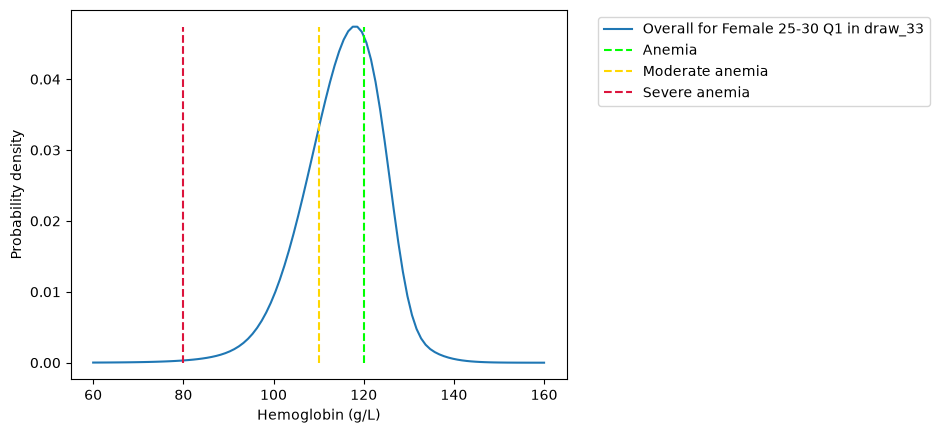

In [84]:
plot_example_distributions({"Overall": hemoglobin_distributions_by_age_sex_quintile})

In [85]:
# Assumption: non-iron-responsive anemias have same distribution of hemoglobin
# as iron-responsive anemias
non_iron_responsive_hemoglobin_distributions = truncate_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    truncate_max=hgb_info.hgb_upper_mild,
)

In [86]:
# Use even more wiggle room, as the issues in the previous check are "magnified"!
test_pdfs_cdfs_consistency(
    non_iron_responsive_hemoglobin_distributions,
    mean_tolerance=0.01,
    max_tolerance=0.10,
)

count    3.069000e+03
mean     2.022073e-03
std      6.572794e-03
min     -4.325730e-07
25%      1.200141e-05
50%      1.470035e-04
75%      9.069929e-04
max      4.811154e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.325730e-07
Female  1.000000   2.0      1                draw_230   -3.545341e-07
        0.076712   0.5      1                draw_183   -3.304741e-07
                            2                draw_107   -2.872284e-07
        1.000000   2.0      4                draw_229   -2.805688e-07
                                                             ...     
Male    90.000000  95.0     3                draw_204    4.549181e-02
                                             draw_126    4.549347e-02
        95.000000  125.0    1                draw_242    4.652250e-02
        90.000000  95.0     1                draw_204    4.708825e-02
        95.000000  125.0    3                draw_57     4.811154e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001972
std         0.006585
min        -0.000242
25%        -0.000019
50%         0.000089
75%         0.000855
max         0.048117
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000242
                                             draw_229   -0.000241
        1.000000   2.0      1                draw_230   -0.000226
Male    0.076712   0.5      2                draw_199   -0.000226
Female  0.076712   0.5      1                draw_183   -0.000225
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.045498
                                             draw_126    0.045499
        95.000000  125.0    1                draw_242    0.046528
        90.000000  95.0     1                draw_204    0.047094
        95.000000  125.0    3                draw_57     0.048117
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000525
std         0.007609
min        -0.016539
25%        -0.004056
50%        -0.001346
75%         0.000149
max         0.048124
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.016539
                            4                draw_238   -0.015357
Female  10.0       15.0     4                draw_139   -0.015338
Male    10.0       15.0     5                draw_31    -0.014965
Female  5.0        10.0     5                draw_14    -0.014645
                                                           ...   
Male    90.0       95.0     3                draw_204    0.045504
                                             draw_126    0.045506
        95.0       125.0    1                draw_242    0.046535
        90.0       95.0     1                draw_204    0.047101
        95.0       125.0    3                draw_57     0.048124
Length: 3069, dtype: float64

count    3069.000000
mean       -0.003166
std         0.008340
min        -0.075853
25%        -0.006325
50%        -0.004017
75%        -0.001773
max         0.046674
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.0        0.019178    5                draw_225   -0.075853
                                              draw_151   -0.058820
      65.0       70.000000   5                draw_229   -0.046146
      35.0       40.000000   4                draw_84    -0.045906
      40.0       45.000000   3                draw_84    -0.044949
                                                            ...   
      90.0       95.000000   3                draw_204    0.043940
                                              draw_126    0.043942
      95.0       125.000000  1                draw_242    0.045006
      90.0       95.000000   1                draw_204    0.045597
      95.0       125.000000  3                draw_57     0.046674
Length: 3069, dtype: float64

count    3069.000000
mean       -0.003166
std         0.008340
min        -0.075853
25%        -0.006325
50%        -0.004017
75%        -0.001773
max         0.046674
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.0        0.019178    5                draw_225   -0.075853
                                              draw_151   -0.058820
      65.0       70.000000   5                draw_229   -0.046146
      35.0       40.000000   4                draw_84    -0.045906
      40.0       45.000000   3                draw_84    -0.044949
                                                            ...   
      90.0       95.000000   3                draw_204    0.043940
                                              draw_126    0.043942
      95.0       125.000000  1                draw_242    0.045006
      90.0       95.000000   1                draw_204    0.045597
      95.0       125.000000  3                draw_57     0.046674
Length: 3069, dtype: float64

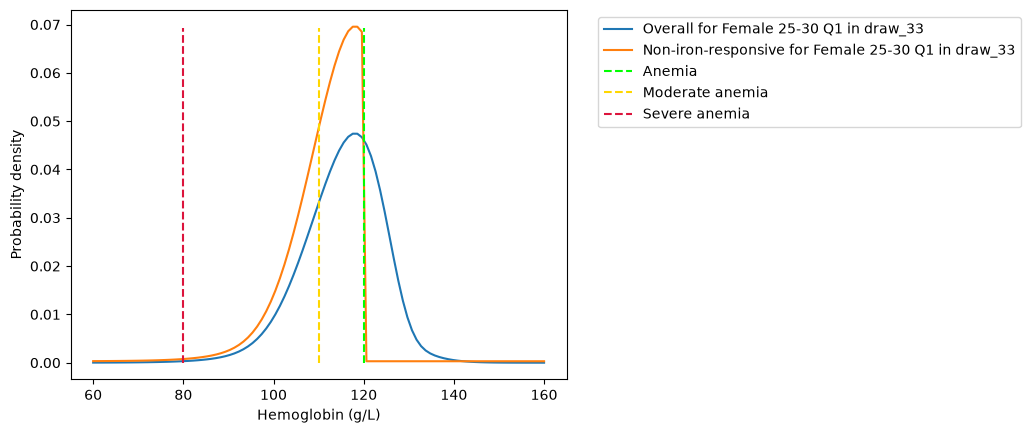

In [87]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    }
)

In [88]:
gbd_hemoglobin_distributions = distributions_from_mean_sd(
    gbd_hgb_mean, gbd_hgb_sd.loc[gbd_hgb_mean.index]
)

In [89]:
gbd_anemia_prevalence = gbd_hemoglobin_distributions.cdfs(
    thresholds.hgb_upper_mild.reindex(gbd_hgb_mean.index)
)
gbd_anemia_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.626276
                               draw_1      0.768911
                               draw_2      0.831913
                               draw_3      0.784510
                               draw_4      0.808747
                                             ...   
Male    95.0       125.000000  draw_245    0.716253
                               draw_246    0.616403
                               draw_247    0.655091
                               draw_248    0.651946
                               draw_249    0.922855
Length: 12500, dtype: float64

In [90]:
non_iron_responsive_anemia_proportion = (
    non_iron_responsive_prevalence / gbd_anemia_prevalence
)
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.106561
                               draw_1      0.106754
                               draw_2      0.081181
                               draw_3      0.077470
                               draw_4      0.091005
                                             ...   
Male    95.0       125.000000  draw_245    0.136968
                               draw_246    0.156175
                               draw_247    0.132163
                               draw_248    0.174856
                               draw_249    0.105731
Length: 12500, dtype: float64

In [91]:
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.106561
                               draw_1      0.106754
                               draw_2      0.081181
                               draw_3      0.077470
                               draw_4      0.091005
                                             ...   
Male    95.0       125.000000  draw_245    0.136968
                               draw_246    0.156175
                               draw_247    0.132163
                               draw_248    0.174856
                               draw_249    0.105731
Length: 12500, dtype: float64

In [92]:
hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.725518
                                                draw_1      0.842047
                                                draw_2      0.868412
                                                draw_3      0.892963
                                                draw_4      0.847660
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.698004
                                                draw_246    0.600463
                                                draw_247    0.641951
                                                draw_248    0.638574
                                                draw_249    0.914350
Length: 62500, dtype: float64

In [93]:
non_iron_responsive_anemia_prevalence_by_age_sex_quintile = (
    (
        non_iron_responsive_anemia_proportion
        * hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)
    )
    .reorder_levels(hgb_info.index.names)
    .reindex(hgb_info.index)
)
non_iron_responsive_anemia_prevalence_by_age_sex_quintile

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.077312
                                                draw_1      0.089892
                                                draw_2      0.070499
                                                draw_3      0.069178
                                                draw_4      0.077141
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.095604
                                                draw_246    0.093777
                                                draw_247    0.084842
                                                draw_248    0.111659
                                                draw_249    0.096675
Length: 62500, dtype: float64

In [94]:
iron_responsive_distributions = delete_from_mixture_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    non_iron_responsive_hemoglobin_distributions,
    non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
)

In [95]:
test_pdfs_cdfs_consistency(
    iron_responsive_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.065795e-03
std      3.893711e-03
min     -4.202344e-07
25%      4.973580e-06
50%      6.077156e-05
75%      3.448601e-04
max      3.218100e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.202344e-07
Female  1.000000   2.0      1                draw_230   -3.320813e-07
        0.076712   0.5      1                draw_183   -2.971956e-07
                            2                draw_107   -2.582216e-07
Male    10.000000  15.0     1                draw_217   -2.542893e-07
                                                             ...     
        90.000000  95.0     3                draw_204    2.935581e-02
        95.000000  125.0    2                draw_15     2.947687e-02
                            1                draw_242    3.002598e-02
        90.000000  95.0     1                draw_204    3.120006e-02
        95.000000  125.0    3                draw_57     3.218100e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001040
std         0.003900
min        -0.000223
25%        -0.000008
50%         0.000035
75%         0.000324
max         0.032185
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000223
                                             draw_229   -0.000222
        1.000000   2.0      1                draw_230   -0.000212
Male    0.500000   1.0      2                draw_228   -0.000209
Female  0.500000   1.0      4                draw_163   -0.000204
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.029360
        95.000000  125.0    2                draw_15     0.029481
                            1                draw_242    0.030030
        90.000000  95.0     1                draw_204    0.031204
        95.000000  125.0    3                draw_57     0.032185
Length: 3069, dtype: float64

count    3069.000000
mean        0.001455
std         0.003834
min        -0.000426
25%         0.000236
50%         0.000639
75%         0.001062
max         0.032189
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    65.000000  70.000000   4                draw_139   -0.000426
        0.019178   0.076712    4                draw_148   -0.000421
Female  0.019178   0.076712    5                draw_31    -0.000371
Male    50.000000  55.000000   1                draw_118   -0.000335
Female  0.019178   0.076712    4                draw_99    -0.000323
                                                              ...   
Male    90.000000  95.000000   3                draw_204    0.029364
        95.000000  125.000000  2                draw_15     0.029485
                               1                draw_242    0.030034
        90.000000  95.000000   1                draw_204    0.031208
        95.000000  125.000000  3                draw_57     0.032189
Length: 3069, dtype: float64

count    3069.000000
mean        0.001699
std         0.003823
min         0.000010
25%         0.000586
50%         0.000826
75%         0.001198
max         0.032426
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    1                draw_99     0.000010
                                                draw_218    0.000016
        0.000000   0.019178    1                draw_3      0.000038
        80.000000  85.000000   2                draw_139    0.000042
Female  0.019178   0.076712    1                draw_139    0.000047
                                                              ...   
Male    90.000000  95.000000   3                draw_204    0.029546
        95.000000  125.000000  2                draw_15     0.029653
                               1                draw_242    0.030262
        90.000000  95.000000   1                draw_204    0.031388
        95.000000  125.000000  3                draw_57     0.032426
Length: 3069, dtype: float64

count    3069.000000
mean        0.001679
std         0.003824
min         0.000010
25%         0.000569
50%         0.000792
75%         0.001172
max         0.032418
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.019178   0.076712    1                draw_99     0.000010
                                              draw_218    0.000016
      0.000000   0.019178    1                draw_3      0.000025
      80.000000  85.000000   2                draw_139    0.000042
      0.000000   0.019178    1                draw_13     0.000046
                                                            ...   
      90.000000  95.000000   3                draw_204    0.029541
      95.000000  125.000000  2                draw_15     0.029646
                             1                draw_242    0.030256
      90.000000  95.000000   1                draw_204    0.031382
      95.000000  125.000000  3                draw_57     0.032418
Length: 3069, dtype: float64

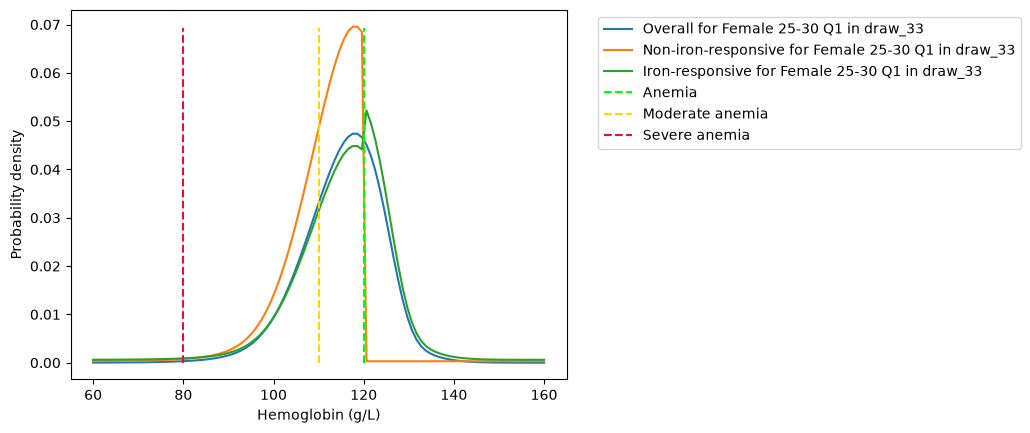

In [96]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive": iron_responsive_distributions,
    }
)

In [97]:
# NOTE: this decomposition, like what we do for wealth quintile above,
# is not exact -- we pretend that these two distributions would mix
# to the overall iron-responsive distribution, but they wouldn't.
# Here, we delete baseline coverage baked into the GBD 2021 distribution
# to get the without-fortification distribution.
# Also note that this and the next shift both assume that the hemoglobin effect among
# the responsive is a fixed value without individual-level variation.
iron_responsive_without_fortification_distributions = shift_distributions(
    iron_responsive_distributions,
    -effective_coverage_2021 * hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [98]:
test_pdfs_cdfs_consistency(
    iron_responsive_without_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.065795e-03
std      3.893711e-03
min     -4.202344e-07
25%      4.973580e-06
50%      6.077156e-05
75%      3.448601e-04
max      3.218100e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.202344e-07
Female  1.000000   2.0      1                draw_230   -3.320813e-07
        0.076712   0.5      1                draw_183   -2.971956e-07
                            2                draw_107   -2.582216e-07
Male    10.000000  15.0     1                draw_217   -2.542893e-07
                                                             ...     
        90.000000  95.0     3                draw_204    2.935581e-02
        95.000000  125.0    2                draw_15     2.947687e-02
                            1                draw_242    3.002598e-02
        90.000000  95.0     1                draw_204    3.120006e-02
        95.000000  125.0    3                draw_57     3.218100e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001040
std         0.003900
min        -0.000223
25%        -0.000008
50%         0.000035
75%         0.000324
max         0.032185
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000223
                                             draw_229   -0.000222
        1.000000   2.0      1                draw_230   -0.000212
Male    0.500000   1.0      2                draw_228   -0.000209
Female  0.500000   1.0      4                draw_163   -0.000204
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.029360
        95.000000  125.0    2                draw_15     0.029481
                            1                draw_242    0.030030
        90.000000  95.0     1                draw_204    0.031204
        95.000000  125.0    3                draw_57     0.032185
Length: 3069, dtype: float64

count    3069.000000
mean        0.001455
std         0.003834
min        -0.000426
25%         0.000236
50%         0.000639
75%         0.001062
max         0.032189
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    65.000000  70.000000   4                draw_139   -0.000426
        0.019178   0.076712    4                draw_148   -0.000421
Female  0.019178   0.076712    5                draw_31    -0.000371
Male    50.000000  55.000000   1                draw_118   -0.000335
Female  0.019178   0.076712    4                draw_99    -0.000323
                                                              ...   
Male    90.000000  95.000000   3                draw_204    0.029364
        95.000000  125.000000  2                draw_15     0.029485
                               1                draw_242    0.030034
        90.000000  95.000000   1                draw_204    0.031208
        95.000000  125.000000  3                draw_57     0.032189
Length: 3069, dtype: float64

count    3069.000000
mean        0.001699
std         0.003823
min         0.000010
25%         0.000586
50%         0.000826
75%         0.001198
max         0.032426
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    1                draw_99     0.000010
                                                draw_218    0.000016
        0.000000   0.019178    1                draw_3      0.000038
        80.000000  85.000000   2                draw_139    0.000042
Female  0.019178   0.076712    1                draw_139    0.000047
                                                              ...   
Male    90.000000  95.000000   3                draw_204    0.029546
        95.000000  125.000000  2                draw_15     0.029653
                               1                draw_242    0.030262
        90.000000  95.000000   1                draw_204    0.031388
        95.000000  125.000000  3                draw_57     0.032426
Length: 3069, dtype: float64

count    3069.000000
mean        0.001679
std         0.003824
min         0.000010
25%         0.000569
50%         0.000792
75%         0.001172
max         0.032418
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.019178   0.076712    1                draw_99     0.000010
                                              draw_218    0.000016
      0.000000   0.019178    1                draw_3      0.000025
      80.000000  85.000000   2                draw_139    0.000042
      0.000000   0.019178    1                draw_13     0.000046
                                                            ...   
      90.000000  95.000000   3                draw_204    0.029541
      95.000000  125.000000  2                draw_15     0.029646
                             1                draw_242    0.030256
      90.000000  95.000000   1                draw_204    0.031382
      95.000000  125.000000  3                draw_57     0.032418
Length: 3069, dtype: float64

In [99]:
iron_responsive_with_fortification_distributions = shift_distributions(
    iron_responsive_without_fortification_distributions,
    hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [100]:
test_pdfs_cdfs_consistency(
    iron_responsive_with_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.070476e-03
std      3.905623e-03
min     -2.801085e-07
25%      5.184534e-06
50%      6.189517e-05
75%      3.479970e-04
max      3.225257e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.000000  15.0     1                draw_217   -2.801085e-07
        0.076712   0.5      2                draw_199   -1.150094e-07
Female  0.076712   0.5      2                draw_238   -1.131814e-07
                                             draw_229   -1.103034e-07
        1.000000   2.0      4                draw_229   -9.176370e-08
                                                             ...     
Male    90.000000  95.0     3                draw_204    2.944017e-02
        95.000000  125.0    2                draw_15     2.957220e-02
                            1                draw_242    3.010745e-02
        90.000000  95.0     1                draw_204    3.128933e-02
        95.000000  125.0    3                draw_57     3.225257e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001049
std         0.003911
min        -0.000205
25%        -0.000004
50%         0.000039
75%         0.000329
max         0.032256
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -0.000205
Female  0.500000   1.0      2                draw_118   -0.000194
Male    2.000000   5.0      1                draw_188   -0.000187
        0.076712   0.5      1                draw_36    -0.000183
Female  1.000000   2.0      1                draw_230   -0.000177
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.029444
        95.000000  125.0    2                draw_15     0.029576
                            1                draw_242    0.030111
        90.000000  95.0     1                draw_204    0.031293
        95.000000  125.0    3                draw_57     0.032256
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000096
std         0.004398
min        -0.019769
25%        -0.001620
50%        -0.000679
75%         0.000036
max         0.032261
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_217   -0.019769
Female  5.0        10.0     1                draw_199   -0.015746
Male    5.0        10.0     2                draw_91    -0.015066
Female  5.0        10.0     1                draw_153   -0.010703
                            2                draw_214   -0.010014
                                                           ...   
Male    90.0       95.0     3                draw_204    0.029448
        95.0       125.0    2                draw_15     0.029581
                            1                draw_242    0.030115
        90.0       95.0     1                draw_204    0.031297
        95.0       125.0    3                draw_57     0.032261
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000437
std         0.004387
min        -0.019733
25%        -0.001789
50%        -0.001085
75%        -0.000409
max         0.031895
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_217   -0.019733
Female  5.0        10.0     1                draw_199   -0.016313
Male    5.0        10.0     2                draw_91    -0.015509
        10.0       15.0     3                draw_131   -0.011788
        30.0       35.0     1                draw_57    -0.011679
                                                           ...   
        90.0       95.0     3                draw_204    0.029204
        95.0       125.0    2                draw_15     0.029374
                            1                draw_242    0.029796
        90.0       95.0     1                draw_204    0.031057
        95.0       125.0    3                draw_57     0.031895
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000465
std         0.004387
min        -0.019736
25%        -0.001809
50%        -0.001114
75%        -0.000435
max         0.031888
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_217   -0.019736
Female  5.0        10.0     1                draw_199   -0.016313
Male    5.0        10.0     2                draw_91    -0.015509
        10.0       15.0     3                draw_131   -0.011788
        30.0       35.0     1                draw_57    -0.011679
                                                           ...   
        90.0       95.0     3                draw_204    0.029200
        95.0       125.0    2                draw_15     0.029369
                            1                draw_242    0.029791
        90.0       95.0     1                draw_204    0.031051
        95.0       125.0    3                draw_57     0.031888
Length: 3069, dtype: float64

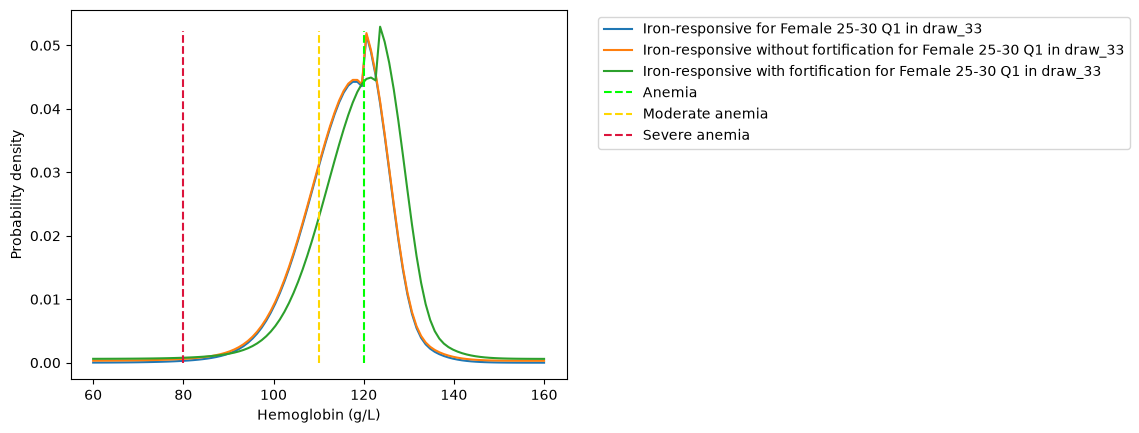

In [101]:
plot_example_distributions(
    {
        "Iron-responsive": iron_responsive_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

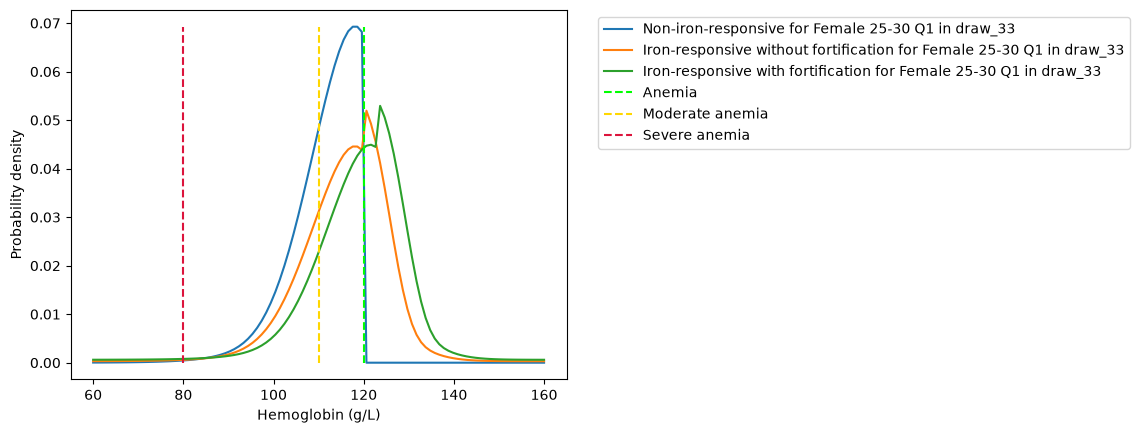

In [102]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

In [103]:
zero_fort_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
    ]
)

In [104]:
test_pdfs_cdfs_consistency(
    zero_fort_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.170089e-03
std      4.174255e-03
min     -4.215423e-07
25%      5.683431e-06
50%      7.120976e-05
75%      4.125419e-04
max      3.435115e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.215423e-07
Female  1.000000   2.0      1                draw_230   -3.343388e-07
        0.076712   0.5      1                draw_183   -3.024550e-07
                            2                draw_107   -2.610426e-07
Male    0.076712   0.5      2                draw_199   -2.511647e-07
                                                             ...     
        90.000000  95.0     3                draw_204    3.097156e-02
                                             draw_126    3.097372e-02
        95.000000  125.0    1                draw_242    3.209781e-02
        90.000000  95.0     1                draw_204    3.282925e-02
        95.000000  125.0    3                draw_57     3.435115e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001141
std         0.004182
min        -0.000226
25%        -0.000010
50%         0.000042
75%         0.000386
max         0.034355
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000226
                                             draw_229   -0.000225
        1.000000   2.0      1                draw_230   -0.000214
Male    0.500000   1.0      2                draw_228   -0.000210
Female  0.076712   0.5      1                draw_183   -0.000206
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.030975
                                             draw_126    0.030978
        95.000000  125.0    1                draw_242    0.032102
        90.000000  95.0     1                draw_204    0.032833
        95.000000  125.0    3                draw_57     0.034355
Length: 3069, dtype: float64

count    3069.000000
mean        0.001203
std         0.004169
min        -0.000516
25%         0.000047
50%         0.000168
75%         0.000460
max         0.034360
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    65.000000  70.000000   4                draw_139   -0.000516
        0.019178   0.076712    4                draw_148   -0.000426
Female  0.019178   0.076712    5                draw_31    -0.000385
Male    35.000000  40.000000   4                draw_118   -0.000369
        50.000000  55.000000   1                draw_118   -0.000362
                                                              ...   
        90.000000  95.000000   3                draw_204    0.030980
                                                draw_126    0.030982
        95.000000  125.000000  1                draw_242    0.032106
        90.000000  95.000000   1                draw_204    0.032838
        95.000000  125.000000  3                draw_57     0.034360
Length: 3069, dtype: float64

count    3069.000000
mean        0.001191
std         0.004174
min        -0.000596
25%         0.000015
50%         0.000113
75%         0.000439
max         0.034367
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    5                draw_225   -5.957049e-04
                                                draw_151   -4.110316e-04
Female  95.0       125.000000  1                draw_181   -3.708145e-14
Male    10.0       15.000000   3                draw_131   -3.241851e-14
Female  85.0       90.000000   1                draw_131    3.674838e-14
                                                                ...     
Male    90.0       95.000000   3                draw_204    3.098769e-02
                                                draw_126    3.098986e-02
        95.0       125.000000  1                draw_242    3.211376e-02
        90.0       95.000000   1                draw_204    3.284512e-02
        95.0       125.000000  3                draw_57     3.436688e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.173310e-03
std      4.176564e-03
min     -1.627587e-13
25%      6.518674e-06
50%      7.359428e-05
75%      4.199419e-04
max      3.436034e-02
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  65.000000  70.000000   5                draw_229   -1.627587e-13
      0.000000   0.019178    4                draw_29    -1.578737e-13
      45.000000  50.000000   5                draw_7     -1.294520e-13
      0.019178   0.076712    5                draw_144   -9.436896e-14
      0.000000   0.019178    1                draw_3     -5.639933e-14
                                                              ...     
      90.000000  95.000000   3                draw_204    3.098243e-02
                                              draw_126    3.098460e-02
      95.000000  125.000000  1                draw_242    3.210819e-02
      90.000000  95.000000   1                draw_204    3.283925e-02
      95.000000  125.000000  3                draw_57     3.436034e-02
Length: 3069, dtype: float64

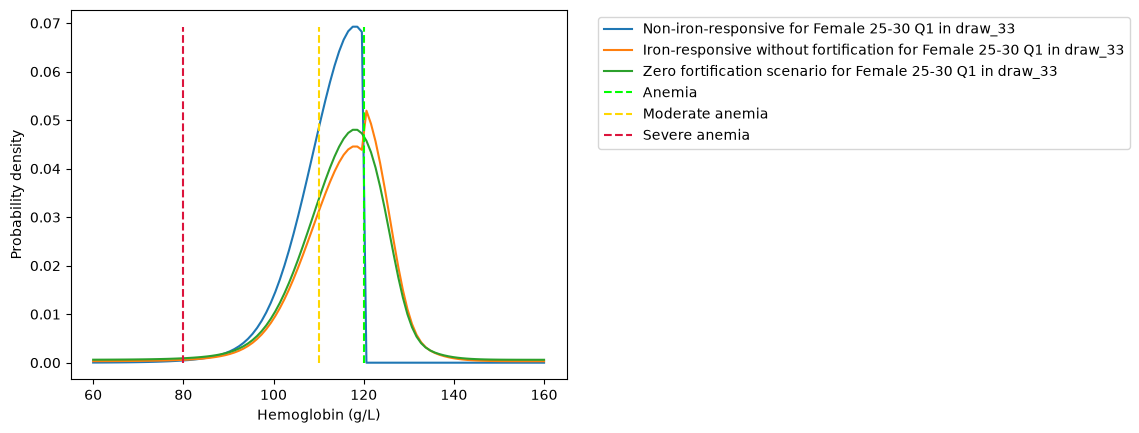

In [105]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Zero fortification scenario": zero_fort_scenario_distributions,
    }
)

In [106]:
baseline_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * (1 - effective_coverage_baseline),
        ),
        (
            iron_responsive_with_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * effective_coverage_baseline,
        ),
    ]
)

In [107]:
test_pdfs_cdfs_consistency(
    baseline_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.170089e-03
std      4.174255e-03
min     -4.215423e-07
25%      5.683431e-06
50%      7.120976e-05
75%      4.125419e-04
max      3.435115e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -4.215423e-07
Female  1.000000   2.0      1                draw_230   -3.343388e-07
        0.076712   0.5      1                draw_183   -3.024550e-07
                            2                draw_107   -2.610426e-07
Male    0.076712   0.5      2                draw_199   -2.511647e-07
                                                             ...     
        90.000000  95.0     3                draw_204    3.097156e-02
                                             draw_126    3.097372e-02
        95.000000  125.0    1                draw_242    3.209781e-02
        90.000000  95.0     1                draw_204    3.282925e-02
        95.000000  125.0    3                draw_57     3.435115e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001141
std         0.004182
min        -0.000226
25%        -0.000010
50%         0.000042
75%         0.000386
max         0.034355
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000226
                                             draw_229   -0.000225
        1.000000   2.0      1                draw_230   -0.000214
Male    0.500000   1.0      2                draw_228   -0.000210
Female  0.076712   0.5      1                draw_183   -0.000206
                                                           ...   
Male    90.000000  95.0     3                draw_204    0.030975
                                             draw_126    0.030978
        95.000000  125.0    1                draw_242    0.032102
        90.000000  95.0     1                draw_204    0.032833
        95.000000  125.0    3                draw_57     0.034355
Length: 3069, dtype: float64

count    3069.000000
mean        0.001203
std         0.004169
min        -0.000516
25%         0.000047
50%         0.000168
75%         0.000460
max         0.034360
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    65.000000  70.000000   4                draw_139   -0.000516
        0.019178   0.076712    4                draw_148   -0.000426
Female  0.019178   0.076712    5                draw_31    -0.000385
Male    35.000000  40.000000   4                draw_118   -0.000369
        50.000000  55.000000   1                draw_118   -0.000362
                                                              ...   
        90.000000  95.000000   3                draw_204    0.030980
                                                draw_126    0.030982
        95.000000  125.000000  1                draw_242    0.032106
        90.000000  95.000000   1                draw_204    0.032838
        95.000000  125.000000  3                draw_57     0.034360
Length: 3069, dtype: float64

count    3069.000000
mean        0.001191
std         0.004174
min        -0.000596
25%         0.000015
50%         0.000113
75%         0.000439
max         0.034367
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.0        0.019178    5                draw_225   -5.957049e-04
                                                draw_151   -4.110316e-04
Female  95.0       125.000000  1                draw_181   -3.708145e-14
Male    10.0       15.000000   3                draw_131   -3.241851e-14
Female  85.0       90.000000   1                draw_131    3.674838e-14
                                                                ...     
Male    90.0       95.000000   3                draw_204    3.098769e-02
                                                draw_126    3.098986e-02
        95.0       125.000000  1                draw_242    3.211376e-02
        90.0       95.000000   1                draw_204    3.284512e-02
        95.0       125.000000  3                draw_57     3.436688e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.173310e-03
std      4.176564e-03
min     -1.627587e-13
25%      6.518674e-06
50%      7.359428e-05
75%      4.199419e-04
max      3.436034e-02
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  65.000000  70.000000   5                draw_229   -1.627587e-13
      0.000000   0.019178    4                draw_29    -1.578737e-13
      45.000000  50.000000   5                draw_7     -1.294520e-13
      0.019178   0.076712    5                draw_144   -9.436896e-14
      0.000000   0.019178    1                draw_3     -5.639933e-14
                                                              ...     
      90.000000  95.000000   3                draw_204    3.098243e-02
                                              draw_126    3.098460e-02
      95.000000  125.000000  1                draw_242    3.210819e-02
      90.000000  95.000000   1                draw_204    3.283925e-02
      95.000000  125.000000  3                draw_57     3.436034e-02
Length: 3069, dtype: float64

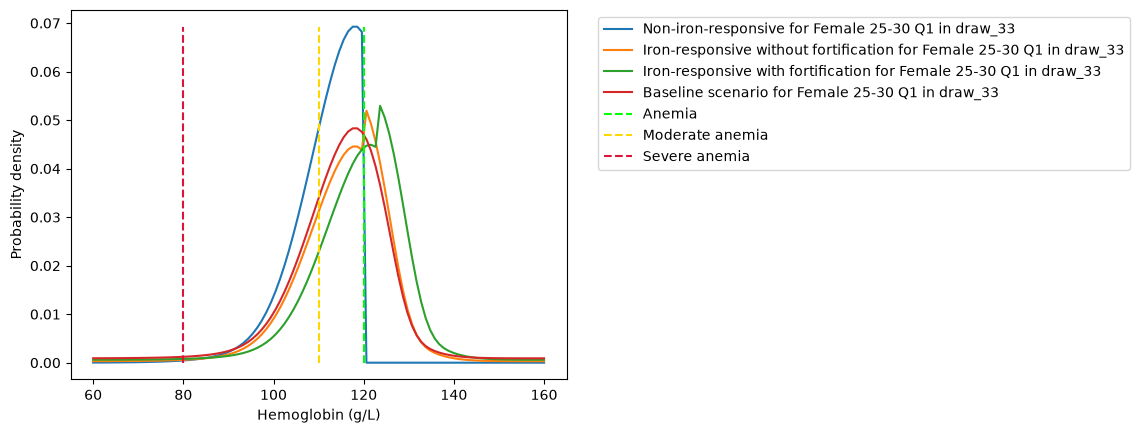

In [108]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
        "Baseline scenario": baseline_scenario_distributions,
    }
)

In [109]:
intervention_scenario_distributions = {}

for intervention_scenario in intervention_scenarios:
    effective_coverage_for_scenario = (
        effective_coverage_intervention[
            effective_coverage_intervention.index.get_level_values("scenario")
            == intervention_scenario
        ]
        .droplevel("scenario")
        .reindex(hgb_info.index)
    )
    intervention_scenario_distributions[intervention_scenario] = mix_distributions(
        [
            (
                non_iron_responsive_hemoglobin_distributions,
                non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
            ),
            (
                iron_responsive_without_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * (1 - effective_coverage_for_scenario),
            ),
            (
                iron_responsive_with_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * effective_coverage_for_scenario,
            ),
        ]
    )

In [110]:
for _, dists in intervention_scenario_distributions.items():
    test_pdfs_cdfs_consistency(
        dists,
        mean_tolerance=0.005,
        max_tolerance=0.05,
    )

count    3.069000e+03
mean     1.170599e-03
std      4.175563e-03
min     -3.731509e-07
25%      5.703899e-06
50%      7.125446e-05
75%      4.128662e-04
max      3.435935e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      2                draw_228   -3.731509e-07
Female  1.000000   2.0      1                draw_230   -3.116161e-07
        0.076712   0.5      1                draw_183   -2.876406e-07
Male    0.076712   0.5      2                draw_199   -2.386588e-07
Female  0.076712   0.5      2                draw_107   -2.368666e-07
                                                             ...     
Male    90.000000  95.0     3                draw_204    3.098163e-02
                                             draw_126    3.098166e-02
        95.000000  125.0    1                draw_242    3.210363e-02
        90.000000  95.0     1                draw_204    3.283579e-02
        95.000000  125.0    3                draw_57     3.435935e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001142
std         0.004183
min        -0.000219
25%        -0.000009
50%         0.000042
75%         0.000386
max         0.034363
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      2                draw_238   -0.000219
                                             draw_229   -0.000217
        1.000000   2.0      1                draw_230   -0.000211
Male    0.500000   1.0      2                draw_228   -0.000210
        2.000000   5.0      1                draw_188   -0.000203
                                                           ...   
        90.000000  95.0     3                draw_204    0.030986
                                             draw_126    0.030986
        95.000000  125.0    1                draw_242    0.032107
        90.000000  95.0     1                draw_204    0.032840
        95.000000  125.0    3                draw_57     0.034363
Length: 3069, dtype: float64

count    3069.000000
mean        0.001031
std         0.004213
min        -0.001148
25%        -0.000139
50%        -0.000011
75%         0.000316
max         0.034368
dtype: float64


sex   age_start  age_end  wealth_quintile  draw    
Male  5.0        10.0     4                draw_214   -0.001148
      10.0       15.0     3                draw_131   -0.001146
                          1                draw_217   -0.001119
      5.0        10.0     5                draw_91    -0.001094
                          4                draw_122   -0.001032
                                                         ...   
      90.0       95.0     3                draw_204    0.030990
                                           draw_126    0.030990
      95.0       125.0    1                draw_242    0.032112
      90.0       95.0     1                draw_204    0.032844
      95.0       125.0    3                draw_57     0.034368
Length: 3069, dtype: float64

count    3069.000000
mean        0.000953
std         0.004222
min        -0.001653
25%        -0.000248
50%        -0.000079
75%         0.000281
max         0.034306
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.001653
        5.0        10.0     4                draw_214   -0.001556
                                             draw_122   -0.001554
Female  10.0       15.0     4                draw_139   -0.001492
Male    5.0        10.0     2                draw_91    -0.001471
                                                           ...   
        90.0       95.0     3                draw_126    0.030930
                                             draw_204    0.030947
        95.0       125.0    1                draw_242    0.032080
        90.0       95.0     1                draw_204    0.032821
        95.0       125.0    3                draw_57     0.034306
Length: 3069, dtype: float64

count    3069.000000
mean        0.000935
std         0.004225
min        -0.001653
25%        -0.000263
50%        -0.000108
75%         0.000253
max         0.034300
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.001653
        5.0        10.0     4                draw_214   -0.001556
                                             draw_122   -0.001554
Female  10.0       15.0     4                draw_139   -0.001492
Male    5.0        10.0     2                draw_91    -0.001471
                                                           ...   
        90.0       95.0     3                draw_126    0.030925
                                             draw_204    0.030942
        95.0       125.0    1                draw_242    0.032075
        90.0       95.0     1                draw_204    0.032815
        95.0       125.0    3                draw_57     0.034300
Length: 3069, dtype: float64

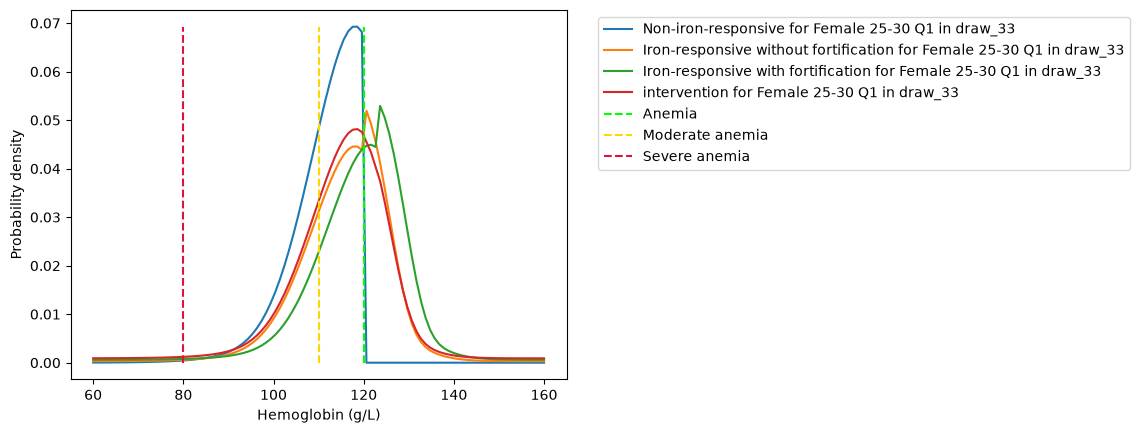

In [111]:
for intervention_scenario in intervention_scenarios:
    plot_example_distributions(
        {
            "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
            "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
            "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
            intervention_scenario: intervention_scenario_distributions[
                intervention_scenario
            ],
        }
    )
    plt.show()

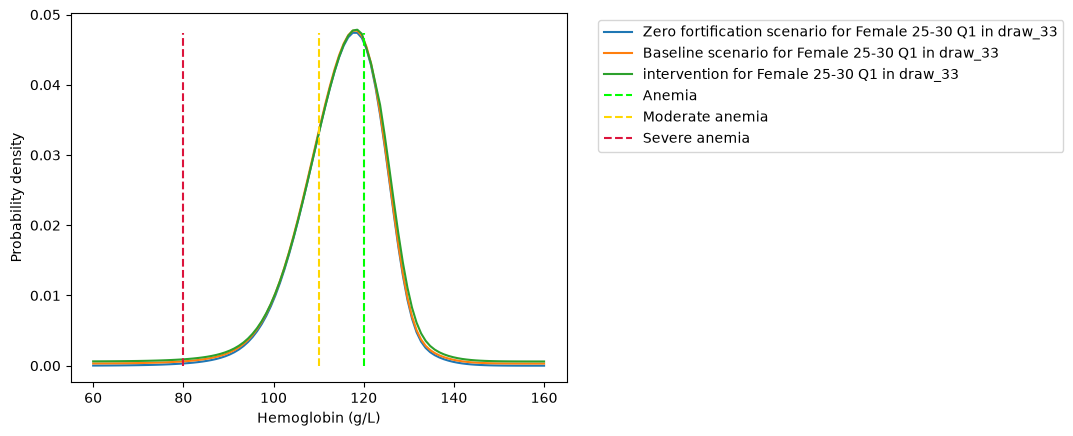

In [112]:
plot_example_distributions(
    {
        "Zero fortification scenario": zero_fort_scenario_distributions,
        "Baseline scenario": baseline_scenario_distributions,
        **intervention_scenario_distributions,
    }
)

In [113]:
def anemia_by_severity_from_distributions(distributions: Distributions):
    result = pd.DataFrame(index=distributions.data_index)
    assert result.index.equals(hgb_info.index)

    result["severe"] = distributions.cdfs(
        hgb_info.hgb_upper_severe.copy()
    ) - distributions.cdfs(hgb_info.hgb_lower_severe.copy())
    result["moderate"] = (
        distributions.cdfs(hgb_info.hgb_upper_moderate.copy()) - result["severe"]
    )
    result["mild"] = (
        distributions.cdfs(hgb_info.hgb_upper_mild.copy())
        - result["moderate"]
        - result["severe"]
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    assert (result >= 0).all().all()
    assert (result <= 1).all().all()
    return result

In [114]:
zero_fort_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    zero_fort_scenario_distributions
)
zero_fort_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.049553  0.434729   
                                            draw_1    0.066828  0.538631   
                                            draw_2    0.171995  0.528587   
                                            draw_3    0.014801  0.542820   
                                            draw_4    0.175217  0.505262   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.179971  0.290595   
                                            draw_246  0.220338  0.225865   
                                            draw_247  0.250646  0.236465   
                                            draw_248  0.248090  0.235640   
                                            draw_249  0.169950  0.456723   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.241236  0.725518  
                                            draw_1    0.236588  0.842047  
                                            draw_2    0.167830  0.868412  
                                            draw_3    0.335342  0.892963  
                                            draw_4    0.167181  0.847660  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.227437  0.698004  
                                            draw_246  0.154260  0.600463  
                                            draw_247  0.154840  0.641951  
                                            draw_248  0.154843  0.638574  
                                            draw_249  0.287677  0.914350  

[62500 rows x 4 columns]

In [115]:
baseline_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    baseline_scenario_distributions
)
baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.049553  0.434729   
                                            draw_1    0.066828  0.538631   
                                            draw_2    0.171995  0.528587   
                                            draw_3    0.014801  0.542820   
                                            draw_4    0.175217  0.505262   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.179971  0.290595   
                                            draw_246  0.220338  0.225865   
                                            draw_247  0.250646  0.236465   
                                            draw_248  0.248090  0.235640   
                                            draw_249  0.169950  0.456723   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.241236  0.725518  
                                            draw_1    0.236588  0.842047  
                                            draw_2    0.167830  0.868412  
                                            draw_3    0.335342  0.892963  
                                            draw_4    0.167181  0.847660  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.227437  0.698004  
                                            draw_246  0.154260  0.600463  
                                            draw_247  0.154840  0.641951  
                                            draw_248  0.154843  0.638574  
                                            draw_249  0.287677  0.914350  

[62500 rows x 4 columns]

In [116]:
intervention_scenarios_anemia_by_severity = {}

for scenario, distributions in intervention_scenario_distributions.items():
    anemia_by_severity = anemia_by_severity_from_distributions(distributions)
    print(scenario)
    display(anemia_by_severity)
    intervention_scenarios_anemia_by_severity[scenario] = anemia_by_severity

intervention


severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.048860  0.431561   
                                            draw_1    0.065845  0.535336   
                                            draw_2    0.170244  0.526998   
                                            draw_3    0.014515  0.536641   
                                            draw_4    0.173563  0.503734   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.177581  0.287700   
                                            draw_246  0.220416  0.222315   
                                            draw_247  0.250916  0.232544   
                                            draw_248  0.248325  0.231934   
                                            draw_249  0.165454  0.452369   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.241212  0.721633  
                                            draw_1    0.237498  0.838678  
                                            draw_2    0.168758  0.866000  
                                            draw_3    0.337396  0.888551  
                                            draw_4    0.167911  0.845209  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.227367  0.692647  
                                            draw_246  0.154104  0.596835  
                                            draw_247  0.154787  0.638247  
                                            draw_248  0.154784  0.635044  
                                            draw_249  0.291652  0.909475  

[62500 rows x 4 columns]

In [117]:
# Transform the intervention scenarios back from a dictionary to the scenario being a level
# in the MultiIndex, which is easier to work with now that we are out of function/distribution space.
intervention_scenarios_anemia_by_severity = pd.concat(
    [
        anemia_by_severity.assign(scenario=scenario).set_index("scenario", append=True)
        for scenario, anemia_by_severity in intervention_scenarios_anemia_by_severity.items()
    ]
)
intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.048860   
                                            draw_1   intervention  0.065845   
                                            draw_2   intervention  0.170244   
                                            draw_3   intervention  0.014515   
                                            draw_4   intervention  0.173563   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.177581   
                                            draw_246 intervention  0.220416   
                                            draw_247 intervention  0.250916   
                                            draw_248 intervention  0.248325   
                                            draw_249 intervention  0.165454   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.431561   
                                            draw_1   intervention  0.535336   
                                            draw_2   intervention  0.526998   
                                            draw_3   intervention  0.536641   
                                            draw_4   intervention  0.503734   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.287700   
                                            draw_246 intervention  0.222315   
                                            draw_247 intervention  0.232544   
                                            draw_248 intervention  0.231934   
                                            draw_249 intervention  0.452369   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.241212   
                                            draw_1   intervention  0.237498   
                                            draw_2   intervention  0.168758   
                                            draw_3   intervention  0.337396   
                                            draw_4   intervention  0.167911   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.227367   
                                            draw_246 intervention  0.154104   
                                            draw_247 intervention  0.154787   
                                            draw_248 intervention  0.154784   
                                            draw_249 intervention  0.291652   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.721633  
                                            draw_1   intervention  0.838678  
                                            draw_2   intervention  0.866000  
                                            draw_3   intervention  0.888551  
                                            draw_4   intervention  0.845209  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.692647  
                                            draw_246 intervention  0.596835  
                                            draw_247 intervention  0.638247  
                                            draw_248 intervention  0.635044  
                                            draw_

In [118]:
zero_fort_scenario_anemia_by_severity - baseline_scenario_anemia_by_severity

severe  moderate  mild  \
sex    age_start age_end    wealth_quintile draw                               
Female 0.0       0.019178   1               draw_0       0.0       0.0   0.0   
                                            draw_1       0.0       0.0   0.0   
                                            draw_2       0.0       0.0   0.0   
                                            draw_3       0.0       0.0   0.0   
                                            draw_4       0.0       0.0   0.0   
...                                                      ...       ...   ...   
Male   95.0      125.000000 5               draw_245     0.0       0.0   0.0   
                                            draw_246     0.0       0.0   0.0   
                                            draw_247     0.0       0.0   0.0   
                                            draw_248     0.0       0.0   0.0   
                                            draw_249     0.0       0.0   0.0   

                                                      anemic  
sex    age_start age_end    wealth_quintile draw              
Female 0.0       0.019178   1               draw_0       0.0  
                                            draw_1       0.0  
                                            draw_2       0.0  
                                            draw_3       0.0  
                                            draw_4       0.0  
...                                                      ...  
Male   95.0      125.000000 5               draw_245     0.0  
                                            draw_246     0.0  
                                            draw_247     0.0  
                                            draw_248     0.0  
                                            draw_249     0.0  

[62500 rows x 4 columns]

In [119]:
baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.000693   
                                            draw_1   intervention  0.000983   
                                            draw_2   intervention  0.001751   
                                            draw_3   intervention  0.000286   
                                            draw_4   intervention  0.001654   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.002391   
                                            draw_246 intervention -0.000078   
                                            draw_247 intervention -0.000270   
                                            draw_248 intervention -0.000235   
                                            draw_249 intervention  0.004496   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.003167   
                                            draw_1   intervention  0.003296   
                                            draw_2   intervention  0.001589   
                                            draw_3   intervention  0.006179   
                                            draw_4   intervention  0.001528   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.002896   
                                            draw_246 intervention  0.003550   
                                            draw_247 intervention  0.003921   
                                            draw_248 intervention  0.003706   
                                            draw_249 intervention  0.004353   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.000024   
                                            draw_1   intervention -0.000910   
                                            draw_2   intervention -0.000928   
                                            draw_3   intervention -0.002053   
                                            draw_4   intervention -0.000731   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.000070   
                                            draw_246 intervention  0.000157   
                                            draw_247 intervention  0.000053   
                                            draw_248 intervention  0.000059   
                                            draw_249 intervention -0.003975   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.003885  
                                            draw_1   intervention  0.003369  
                                            draw_2   intervention  0.002412  
                                            draw_3   intervention  0.004411  
                                            draw_4   intervention  0.002451  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.005356  
                                            draw_246 intervention  0.003628  
                                            draw_247 intervention  0.003704  
                                            draw_248 intervention  0.003530  
                                            draw_

<Axes: >

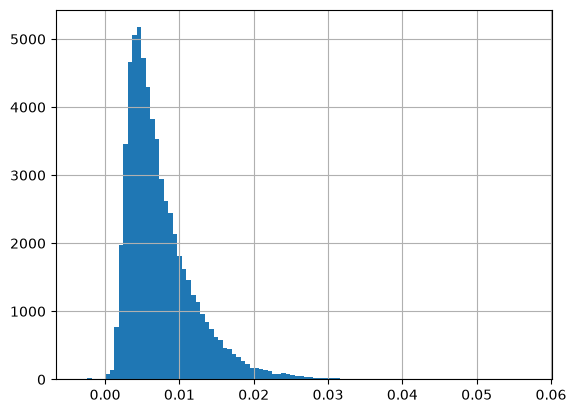

In [120]:
# We can see that in very rare cases, likely due to numerical instability, we get a negative impact
(
    baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity
).anemic.hist(bins=100)

In [121]:
def anemia_by_severity_to_yld_rates(anemia_by_severity):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia_by_severity.index
    anemia_by_severity = (
        anemia_by_severity.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia_by_severity["mild_yld_rate"] = (
        anemia_by_severity.mild * anemia_by_severity.mild_dw
    )
    anemia_by_severity["moderate_yld_rate"] = (
        anemia_by_severity.moderate * anemia_by_severity.moderate_dw
    )
    anemia_by_severity["severe_yld_rate"] = (
        anemia_by_severity.severe * anemia_by_severity.severe_dw
    )
    anemia_by_severity["anemic_yld_rate"] = (
        anemia_by_severity["mild_yld_rate"]
        + anemia_by_severity["moderate_yld_rate"]
        + anemia_by_severity["severe_yld_rate"]
    )

    return anemia_by_severity.set_index(orig_index.names).filter(like="yld_rate")

In [122]:
zero_fort_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    zero_fort_scenario_anemia_by_severity
)
zero_fort_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000584   
                            2               draw_0         0.000609   
                            3               draw_0         0.000614   
                            4               draw_0         0.000641   
                            5               draw_0         0.000611   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.001281   
                            2               draw_249       0.001369   
                            3               draw_249       0.001392   
                            4               draw_249       0.001420   
                            5               draw_249       0.001531   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.025780   
                            2               draw_0             0.023051   
                            3               draw_0             0.019420   
                            4               draw_0             0.017768   
                            5               draw_0             0.012385   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.034010   
                            2               draw_249           0.033819   
                            3               draw_249           0.033229   
                            4               draw_249           0.033629   
                            5               draw_249           0.033712   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.009858   
                            2               draw_0           0.006819   
                            3               draw_0           0.004485   
                            4               draw_0           0.003207   
                            5               draw_0           0.001626   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.043929   
                            2               draw_249         0.039738   
                            3               draw_249         0.039026   
                            4               draw_249         0.037364   
                            5               draw_249         0.032108   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.036222  
                            2               draw_0           0.030479  
                            3               draw_0           0.024519  
                            4               draw_0           0.021617  
                            5               draw_0           0.014621  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.079219  
                            2               draw_249         0.074925  
                            3               draw_249         0.073647  
                            4               draw_249         0.072413  
                            5               draw_249         0.067351  

[62500 rows x 4 columns]

In [123]:
baseline_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    baseline_scenario_anemia_by_severity
)
baseline_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000584   
                            2               draw_0         0.000609   
                            3               draw_0         0.000614   
                            4               draw_0         0.000641   
                            5               draw_0         0.000611   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.001281   
                            2               draw_249       0.001369   
                            3               draw_249       0.001392   
                            4               draw_249       0.001420   
                            5               draw_249       0.001531   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.025780   
                            2               draw_0             0.023051   
                            3               draw_0             0.019420   
                            4               draw_0             0.017768   
                            5               draw_0             0.012385   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.034010   
                            2               draw_249           0.033819   
                            3               draw_249           0.033229   
                            4               draw_249           0.033629   
                            5               draw_249           0.033712   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.009858   
                            2               draw_0           0.006819   
                            3               draw_0           0.004485   
                            4               draw_0           0.003207   
                            5               draw_0           0.001626   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.043929   
                            2               draw_249         0.039738   
                            3               draw_249         0.039026   
                            4               draw_249         0.037364   
                            5               draw_249         0.032108   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.036222  
                            2               draw_0           0.030479  
                            3               draw_0           0.024519  
                            4               draw_0           0.021617  
                            5               draw_0           0.014621  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.079219  
                            2               draw_249         0.074925  
                            3               draw_249         0.073647  
                            4               draw_249         0.072413  
                            5               draw_249         0.067351  

[62500 rows x 4 columns]

In [124]:
intervention_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    intervention_scenarios_anemia_by_severity
)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Female 0.0       0.019178   1               draw_0   intervention       0.000584   
                            2               draw_0   intervention       0.000607   
                            3               draw_0   intervention       0.000611   
                            4               draw_0   intervention       0.000637   
                            5               draw_0   intervention       0.000602   
...                                                                          ...   
Male   95.0      125.000000 1               draw_249 intervention       0.001292   
                            2               draw_249 intervention       0.001384   
                            3               draw_249 intervention       0.001409   
                            4               draw_249 intervention       0.001440   
                            5               draw_249 intervention       0.001552   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Female 0.0       0.019178   1               draw_0   intervention           0.025592   
                            2               draw_0   intervention           0.022788   
                            3               draw_0   intervention           0.019103   
                            4               draw_0   intervention           0.017389   
                            5               draw_0   intervention           0.012036   
...                                                                              ...   
Male   95.0      125.000000 1               draw_249 intervention           0.033902   
                            2               draw_249 intervention           0.033653   
                            3               draw_249 intervention           0.033023   
                            4               draw_249 intervention           0.033375   
                            5               draw_249 intervention           0.033390   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention         0.009720   
                            2               draw_0   intervention         0.006689   
                            3               draw_0   intervention         0.004382   
                            4               draw_0   intervention         0.003120   
                            5               draw_0   intervention         0.001579   
...                                                                            ...   
Male   95.0      125.000000 1               draw_249 intervention         0.043442   
                            2               draw_249 intervention         0.039118   
                            3               draw_249 intervention         0.038291   
                            4               draw_249 intervention         0.036516   
                            5               draw_249 intervention         0.031259   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Female 0.0       0.019178   1               draw_0   intervention         0.035896  
                            2               draw_0   intervention         0.030084  
                            3               draw_0   intervention         0.024096  
                            4               draw_0   intervention         0.021146  
                            5               draw_0   intervention         0.014217  
...                                                                            ...  
Male   95.0      125.000000 1 

In [125]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                      
Male   10.000000 15.000000 2               draw_217 intervention  -5.629497e-06   
                           1               draw_217 intervention  -4.250900e-06   
                           4               draw_217 intervention  -7.396052e-06   
                           3               draw_217 intervention  -6.292275e-06   
                           1               draw_36  intervention  -3.426534e-06   
...                                                                         ...   
       0.019178  0.076712  1               draw_45  intervention  -1.701987e-04   
       0.500000  1.000000  4               draw_19  intervention  -1.091002e-05   
       0.076712  0.500000  4               draw_45  intervention   4.053349e-05   
Female 0.076712  0.500000  4               draw_45  intervention   1.149008e-04   
       0.500000  1.000000  4               draw_19  intervention  -6.548152e-07   

                                                                  moderate_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                          
Male   10.000000 15.000000 2               draw_217 intervention          -0.000084   
                           1               draw_217 intervention          -0.000085   
                           4               draw_217 intervention          -0.000082   
                           3               draw_217 intervention          -0.000076   
                           1               draw_36  intervention          -0.000063   
...                                                                             ...   
       0.019178  0.076712  1               draw_45  intervention           0.001681   
       0.500000  1.000000  4               draw_19  intervention           0.001375   
       0.076712  0.500000  4               draw_45  intervention           0.001432   
Female 0.076712  0.500000  4               draw_45  intervention           0.001426   
       0.500000  1.000000  4               draw_19  intervention           0.001506   

                                                                  severe_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                        
Male   10.000000 15.000000 2               draw_217 intervention        -0.000004   
                           1               draw_217 intervention        -0.000005   
                           4               draw_217 intervention        -0.000003   
                           3               draw_217 intervention        -0.000003   
                           1               draw_36  intervention        -0.000001   
...                                                                           ...   
       0.019178  0.076712  1               draw_45  intervention         0.000002   
       0.500000  1.000000  4               draw_19  intervention         0.000168   
       0.076712  0.500000  4               draw_45  intervention         0.000067   
Female 0.076712  0.500000  4               draw_45  intervention         0.000014   
       0.500000  1.000000  4               draw_19  intervention         0.000063   

                                                                  anemic_yld_rate  
sex    age_start age_end   wealth_quintile draw     scenario                       
Male   10.000000 15.000000 2               draw_217 intervention        -0.000094  
                           1               draw_217 intervention        -0.000093  
                           4               draw_217 intervention        -0.000092  
                           3               draw_217 intervention        -0.000086  
                           1               draw_36  intervention        -0.000068  
...                                                                           ...  
       0.019178  0.076712  1               draw_45  intervention         0.0

<Axes: >

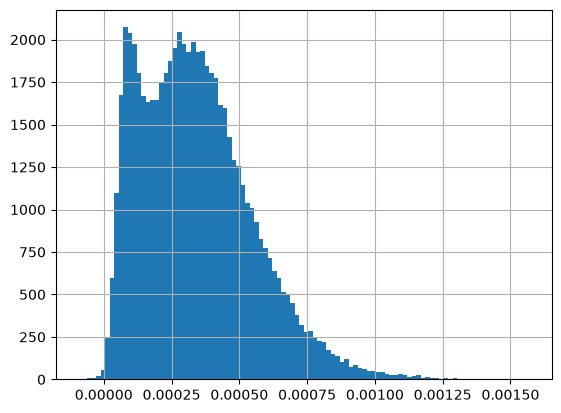

In [126]:
(
    baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates
).anemic_yld_rate.hist(bins=100)

In [127]:
zero_fort_scenario_ylds = (
    zero_fort_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  800.283562
                               2                  706.841012
                               3                  572.445535
                               4                  465.318737
                               5                  335.008818
                                                     ...    
Male    95.0       125.000000  1                  287.520542
                               2                  240.052452
                               3                  243.734762
                               4                  256.767585
                               5                  256.875045
Length: 250, dtype: float64

In [128]:
baseline_scenario_ylds = (
    baseline_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  800.283562
                               2                  706.841012
                               3                  572.445535
                               4                  465.318737
                               5                  335.008818
                                                     ...    
Male    95.0       125.000000  1                  287.520542
                               2                  240.052452
                               3                  243.734762
                               4                  256.767585
                               5                  256.875045
Length: 250, dtype: float64

In [129]:
intervention_scenarios_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_scenarios_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    794.482833
                               2                intervention    699.414984
                               3                intervention    564.447108
                               4                intervention    457.246230
                               5                intervention    327.922478
                                                                   ...    
Male    95.0       125.000000  1                intervention    286.403297
                               2                intervention    238.717041
                               3                intervention    242.112364
                               4                intervention    254.669907
                               5                intervention    254.357830
Length: 250, dtype: float64

In [130]:
(
    baseline_scenario_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_scenarios_ylds.loc[("Female", 25, 30, 1)].mean()
)

342.67013666552157

In [131]:
(
    baseline_scenario_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_scenarios_ylds.groupby(["scenario", "wealth_quintile"]).sum()
)

scenario      wealth_quintile
intervention  1                  12293.888643
              2                  14757.204260
              3                  16203.362286
              4                  18020.423291
              5                  15112.053226
dtype: float64

In [132]:
ylds = pd.concat(
    [
        zero_fort_scenario_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_scenario_ylds.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_scenarios_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,800.283562,zero
1,Female,0.0,0.019178,2,706.841012,zero
2,Female,0.0,0.019178,3,572.445535,zero
3,Female,0.0,0.019178,4,465.318737,zero
4,Female,0.0,0.019178,5,335.008818,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,286.403297,intervention
746,Male,95.0,125.000000,2,238.717041,intervention
747,Male,95.0,125.000000,3,242.112364,intervention
748,Male,95.0,125.000000,4,254.669907,intervention


In [133]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [134]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [135]:
zero_fort_anemia_prevalence = (
    zero_fort_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.846252
                               2                  0.816000
                               3                  0.767945
                               4                  0.760255
                               5                  0.678260
                                                    ...   
Male    95.0       125.000000  1                  0.776843
                               2                  0.765233
                               3                  0.757423
                               4                  0.757979
                               5                  0.747969
Length: 250, dtype: float64

In [136]:
baseline_anemia_prevalence = (
    baseline_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.846252
                               2                  0.816000
                               3                  0.767945
                               4                  0.760255
                               5                  0.678260
                                                    ...   
Male    95.0       125.000000  1                  0.776843
                               2                  0.765233
                               3                  0.757423
                               4                  0.757979
                               5                  0.747969
Length: 250, dtype: float64

In [137]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14769.329314
                               2                  14182.900679
                               3                  12601.737191
                               4                  10966.456900
                               5                   9094.030016
                                                      ...     
Male    95.0       125.000000  1                   3927.806343
                               2                   3385.952068
                               3                   3444.943564
                               4                   3691.523203
                               5                   3884.206679
Length: 250, dtype: float64

In [138]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.4643829363257278

In [139]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14769.329314
                               2                  14182.900679
                               3                  12601.737191
                               4                  10966.456900
                               5                   9094.030016
                                                      ...     
Male    95.0       125.000000  1                   3927.806343
                               2                   3385.952068
                               3                   3444.943564
                               4                   3691.523203
                               5                   3884.206679
Length: 250, dtype: float64

In [140]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.4643829363257278

In [141]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.562449
2    0.504143
3    0.458754
4    0.440851
5    0.357523
dtype: float64

In [142]:
intervention_anemia_prevalence = (
    intervention_scenarios_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.843277
                               2                intervention    0.811402
                               3                intervention    0.761485
                               4                intervention    0.752142
                               5                intervention    0.668336
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.774847
                               2                intervention    0.762429
                               3                intervention    0.753969
                               4                intervention    0.753897
                               5                intervention    0.743312
Length: 250, dtype: float64

In [143]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.846252,zero
1,Female,0.0,0.019178,2,0.816000,zero
2,Female,0.0,0.019178,3,0.767945,zero
3,Female,0.0,0.019178,4,0.760255,zero
4,Female,0.0,0.019178,5,0.678260,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.774847,intervention
746,Male,95.0,125.000000,2,0.762429,intervention
747,Male,95.0,125.000000,3,0.753969,intervention
748,Male,95.0,125.000000,4,0.753897,intervention


In [144]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [145]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    14717.395333
                               2                intervention    14102.972526
                               3                intervention    12495.734110
                               4                intervention    10849.432658
                               5                intervention     8960.976256
                                                                    ...     
Male    95.0       125.000000  1                intervention     3917.711147
                               2                intervention     3373.545142
                               3                intervention     3429.236719
                               4                intervention     3671.643364
                               5                intervention     3860.021303
Length: 250, dtype: float64

In [146]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.4568848171390492

In [147]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.557591
2    0.497596
3    0.450926
4    0.431732
5    0.348436
dtype: float64

In [148]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    225,796
2    305,784
3    367,445
4    431,886
5    428,298
dtype: object

In [149]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,14769.329314,zero
1,Female,0.0,0.019178,2,14182.900679,zero
2,Female,0.0,0.019178,3,12601.737191,zero
3,Female,0.0,0.019178,4,10966.456900,zero
4,Female,0.0,0.019178,5,9094.030016,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,3917.711147,intervention
746,Male,95.0,125.000000,2,3373.545142,intervention
747,Male,95.0,125.000000,3,3429.236719,intervention
748,Male,95.0,125.000000,4,3671.643364,intervention


In [150]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)